This notebook is intended to be the one where I gather the results for the GETLM.

In [4]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
# from python_files import TLM_tests as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM_ensemble as LETLMC
from Python_files import IETLM_ensemble as IETLMC
from Python_files import GETLM as GETLMC


#  We also need to set the precision to be higher as we are working with very small perturbations
torch.set_default_dtype(torch.float64)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# I will also be defining a L2 norm function
def L2_norm(result, reality):
    L2 = sum(abs(result - reality))/sum(abs(reality))
    return L2

In [6]:
# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [7]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

100%|██████████| 999/999 [00:00<00:00, 10467.21it/s]


In [37]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_CN = [-2,-1,0,1]
stencil_members_current_CN = [-2,-1,0,1]
stencil_members_past_CN = []
stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_CN = 9 + len(stencil_members_future_CN) + len(stencil_members_current_CN) + len(stencil_members_past_CN)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final, Ensemble_final, Ensembles =  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_CN, SD_pert, model, model_parameters, Test_pert, number_of_steps = 40)


This may need to be modified to perturb the past state variable

In [38]:
IETLM_STENCIL_LARGE = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE = [[0],[-8,7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6]]


In [39]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 1 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k, plot = False)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    LETLMS.append(M_tilde)


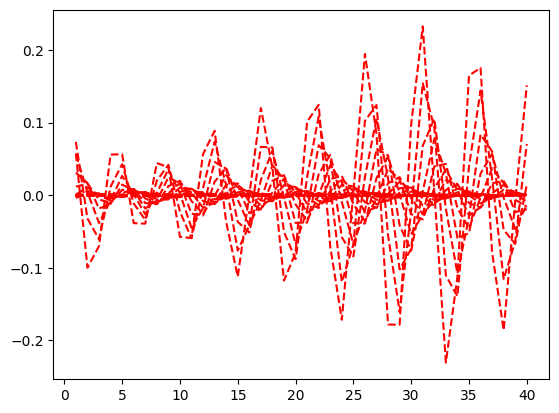

In [40]:
for i in range(len(test_final)):
    plt.plot(x_values, test_final[i].detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')


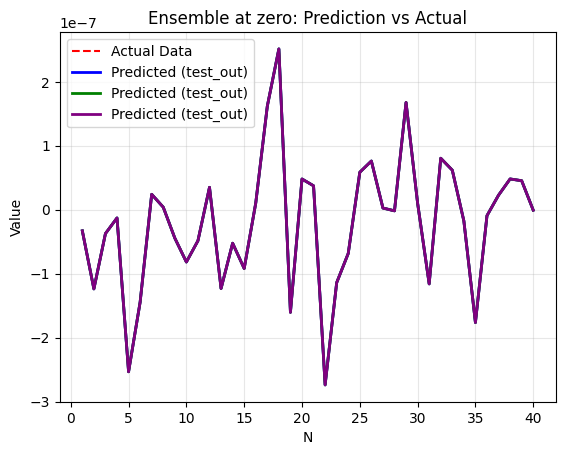

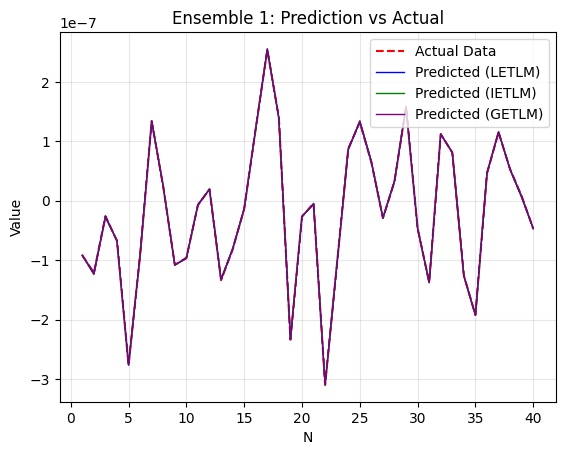

IETLM norm: tensor(0.0086)
LETLM norm: tensor(3.1437e-08)
GETLM norm: tensor(0.0086)


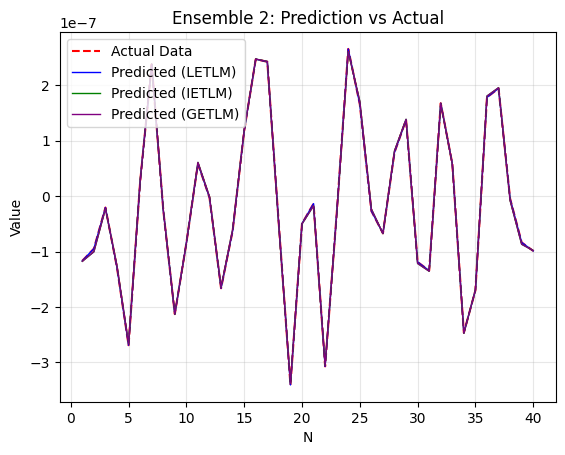

IETLM norm: tensor(0.0148)
LETLM norm: tensor(7.5638e-08)
GETLM norm: tensor(0.0148)


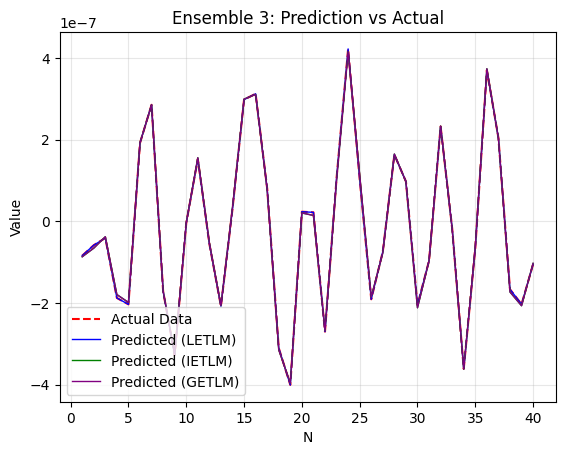

IETLM norm: tensor(0.0190)
LETLM norm: tensor(1.0769e-07)
GETLM norm: tensor(0.0190)


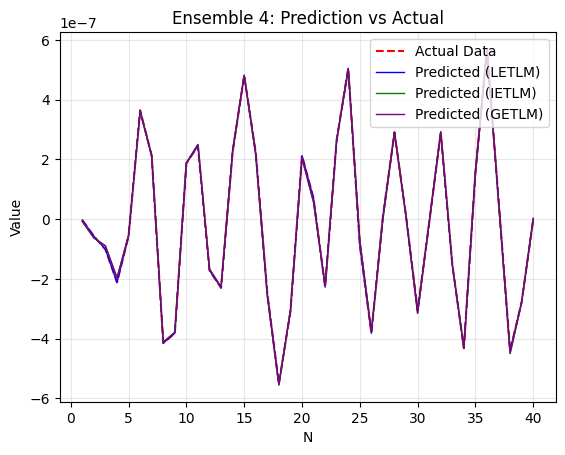

IETLM norm: tensor(0.0216)
LETLM norm: tensor(1.7755e-07)
GETLM norm: tensor(0.0216)


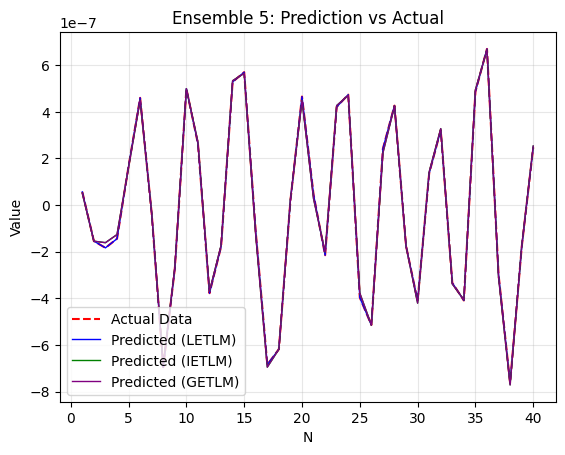

IETLM norm: tensor(0.0219)
LETLM norm: tensor(1.7107e-07)
GETLM norm: tensor(0.0219)


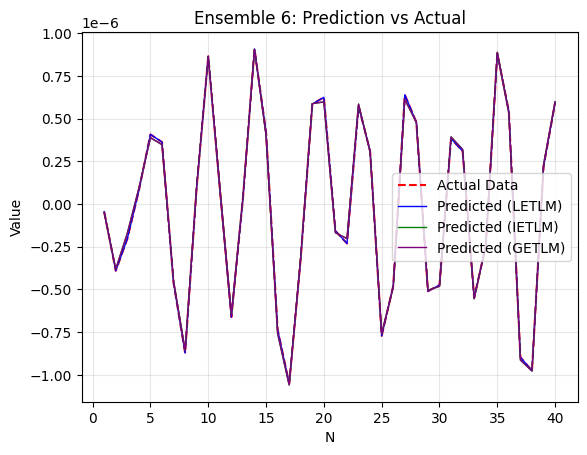

IETLM norm: tensor(0.0228)
LETLM norm: tensor(2.5311e-07)
GETLM norm: tensor(0.0228)


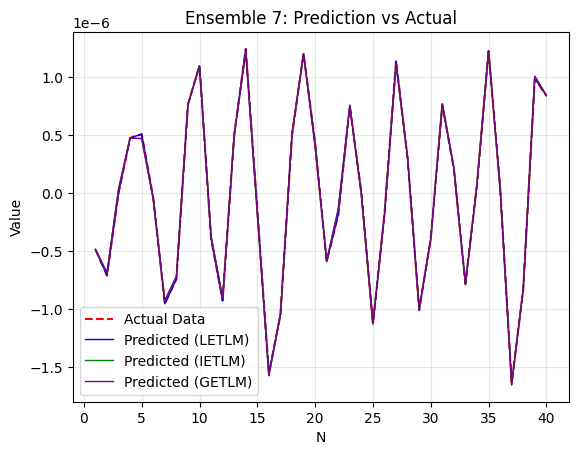

IETLM norm: tensor(0.0232)
LETLM norm: tensor(3.5423e-07)
GETLM norm: tensor(0.0232)


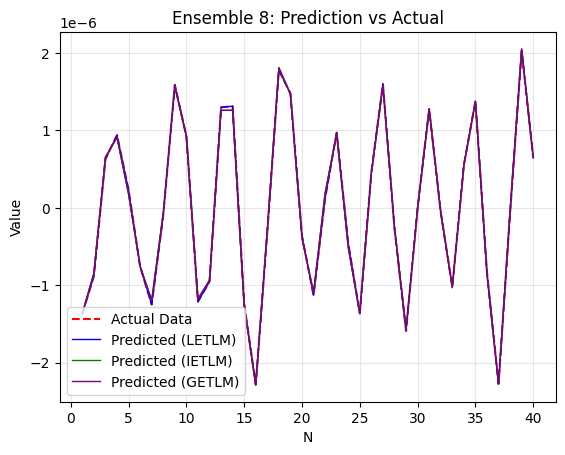

IETLM norm: tensor(0.0227)
LETLM norm: tensor(4.0846e-07)
GETLM norm: tensor(0.0227)


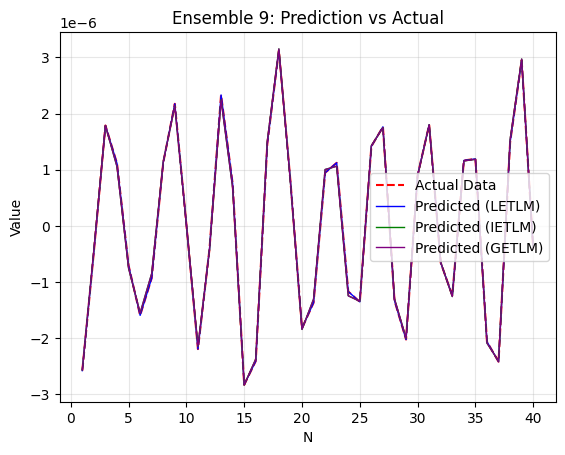

IETLM norm: tensor(0.0210)
LETLM norm: tensor(6.2254e-07)
GETLM norm: tensor(0.0210)


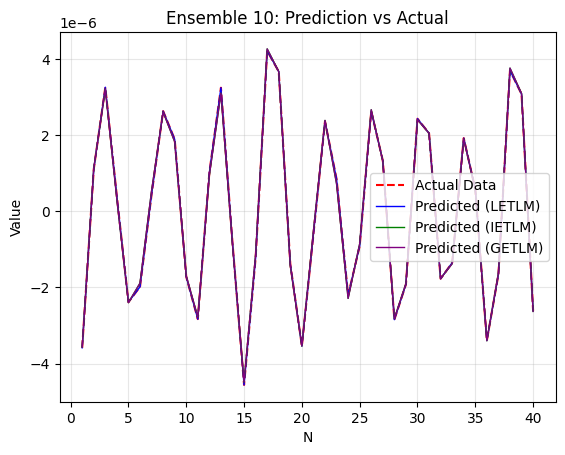

IETLM norm: tensor(0.0204)
LETLM norm: tensor(1.0136e-06)
GETLM norm: tensor(0.0204)


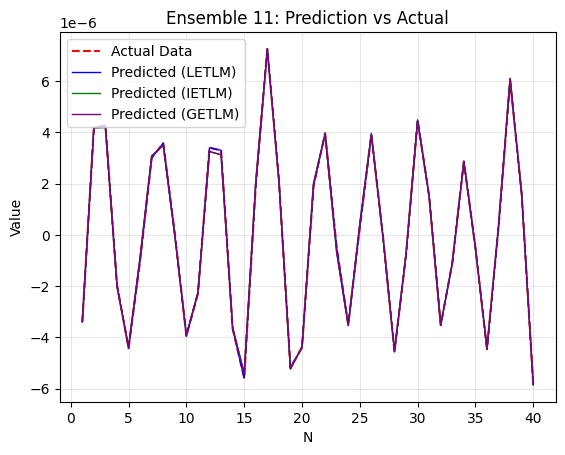

IETLM norm: tensor(0.0205)
LETLM norm: tensor(1.3773e-06)
GETLM norm: tensor(0.0205)


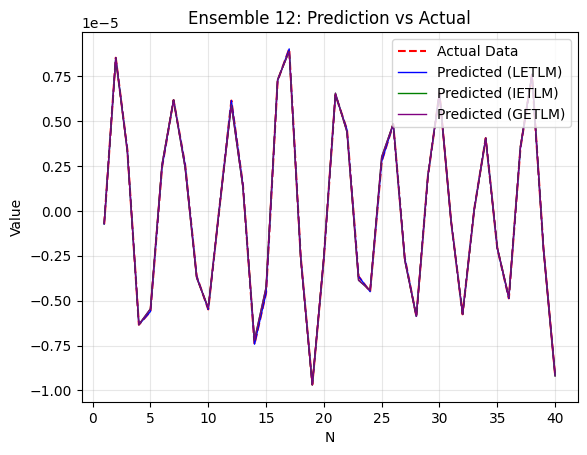

IETLM norm: tensor(0.0197)
LETLM norm: tensor(1.6052e-06)
GETLM norm: tensor(0.0197)


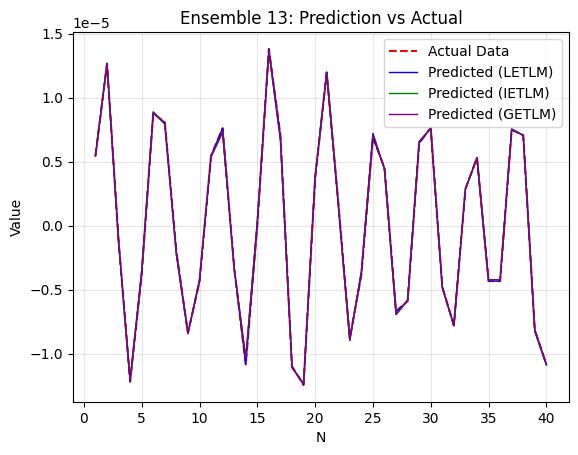

IETLM norm: tensor(0.0195)
LETLM norm: tensor(1.8282e-06)
GETLM norm: tensor(0.0195)


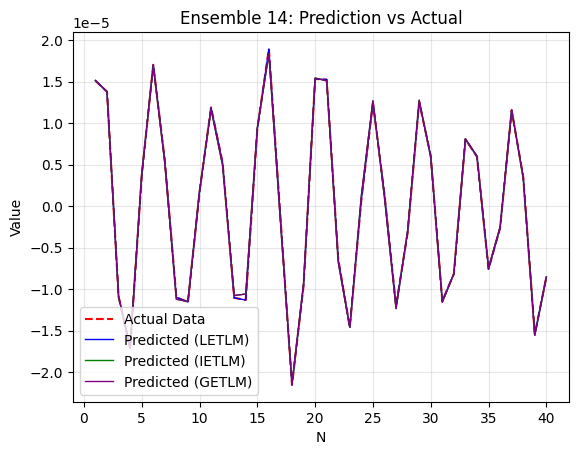

IETLM norm: tensor(0.0201)
LETLM norm: tensor(2.6709e-06)
GETLM norm: tensor(0.0201)


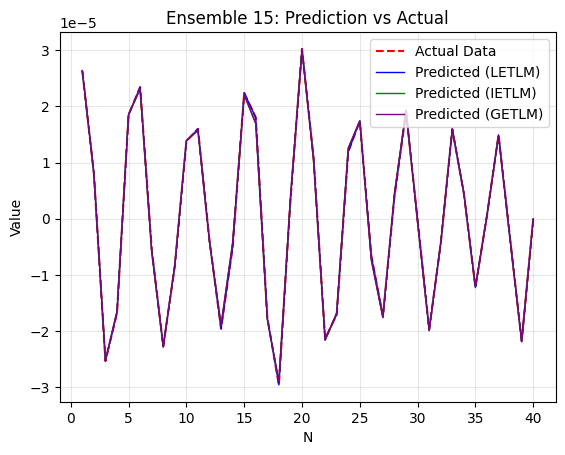

IETLM norm: tensor(0.0209)
LETLM norm: tensor(3.6881e-06)
GETLM norm: tensor(0.0209)


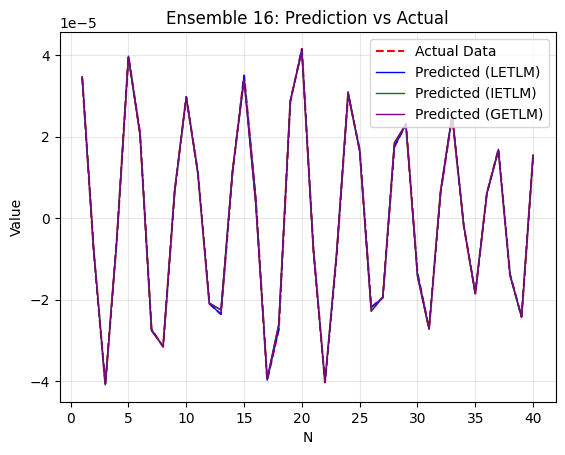

IETLM norm: tensor(0.0197)
LETLM norm: tensor(5.8273e-06)
GETLM norm: tensor(0.0197)


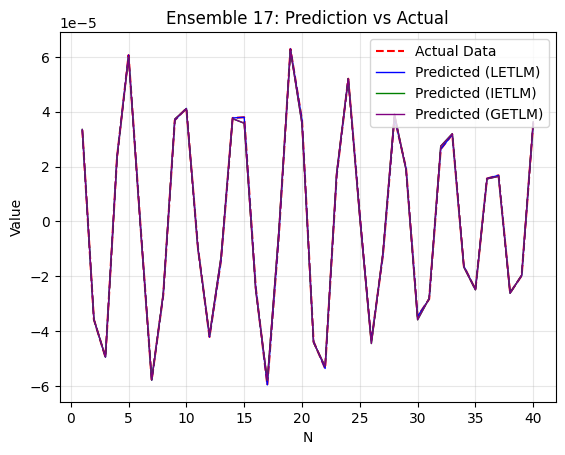

IETLM norm: tensor(0.0201)
LETLM norm: tensor(1.0207e-05)
GETLM norm: tensor(0.0201)


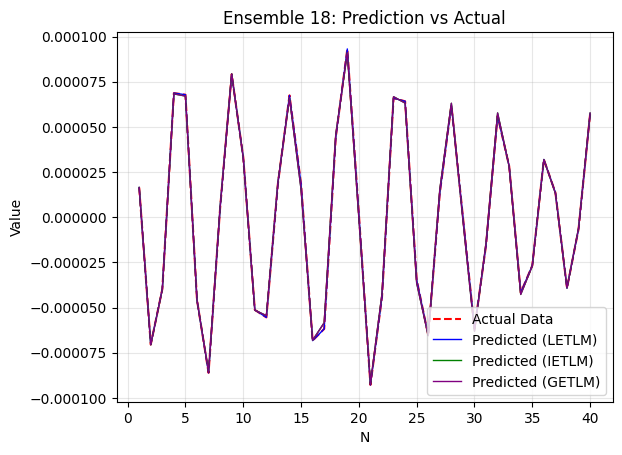

IETLM norm: tensor(0.0206)
LETLM norm: tensor(1.7675e-05)
GETLM norm: tensor(0.0206)


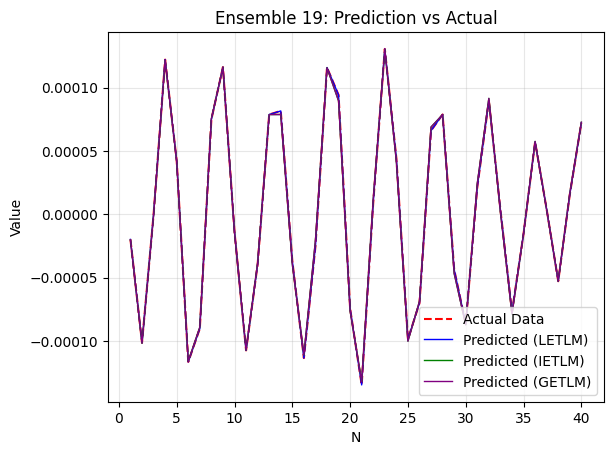

IETLM norm: tensor(0.0207)
LETLM norm: tensor(3.3922e-05)
GETLM norm: tensor(0.0207)


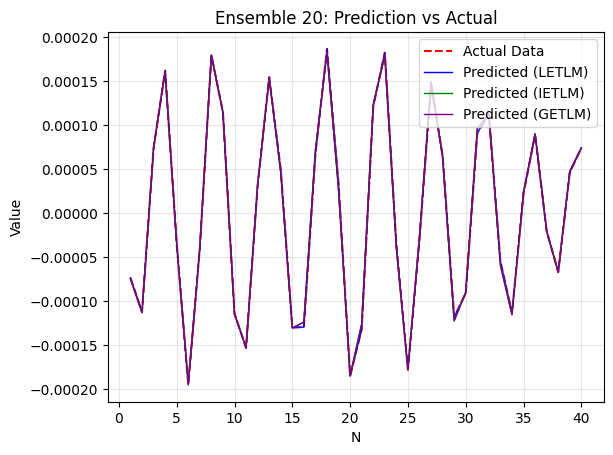

IETLM norm: tensor(0.0202)
LETLM norm: tensor(5.3795e-05)
GETLM norm: tensor(0.0202)


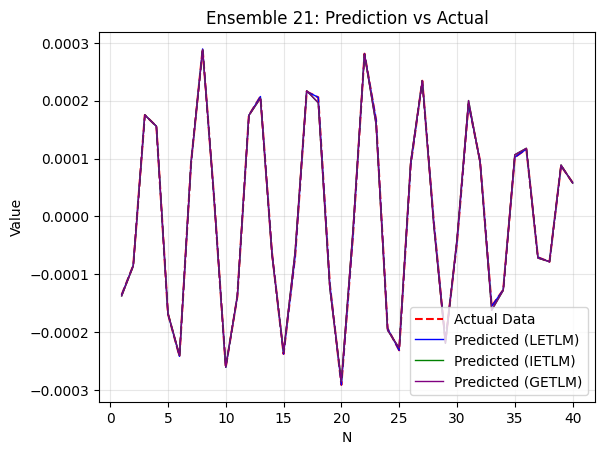

IETLM norm: tensor(0.0205)
LETLM norm: tensor(7.9662e-05)
GETLM norm: tensor(0.0205)


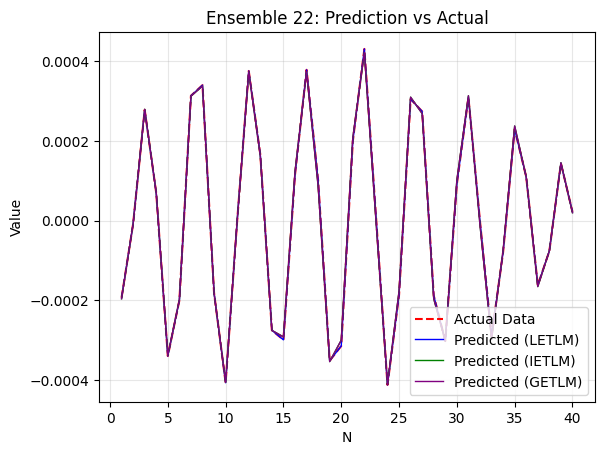

IETLM norm: tensor(0.0214)
LETLM norm: tensor(0.0001)
GETLM norm: tensor(0.0214)


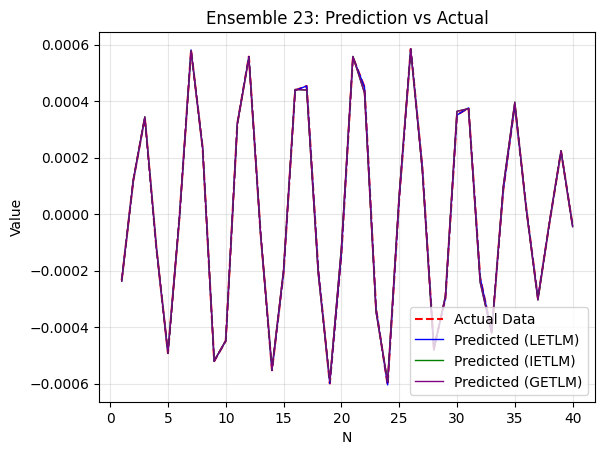

IETLM norm: tensor(0.0220)
LETLM norm: tensor(0.0002)
GETLM norm: tensor(0.0220)


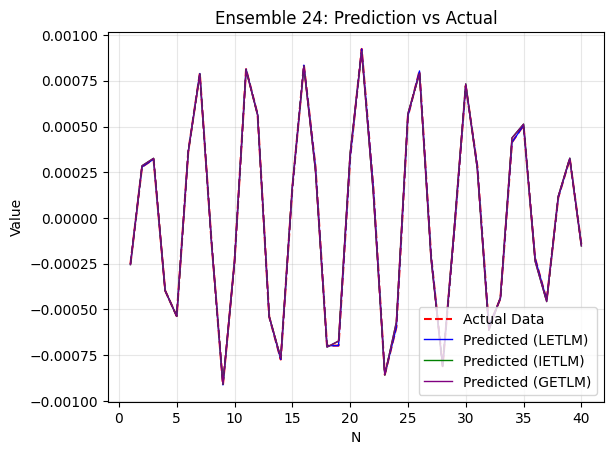

IETLM norm: tensor(0.0215)
LETLM norm: tensor(0.0002)
GETLM norm: tensor(0.0215)


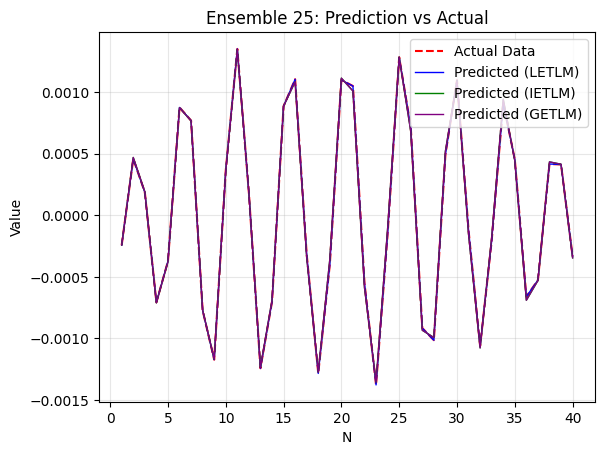

IETLM norm: tensor(0.0215)
LETLM norm: tensor(0.0003)
GETLM norm: tensor(0.0215)


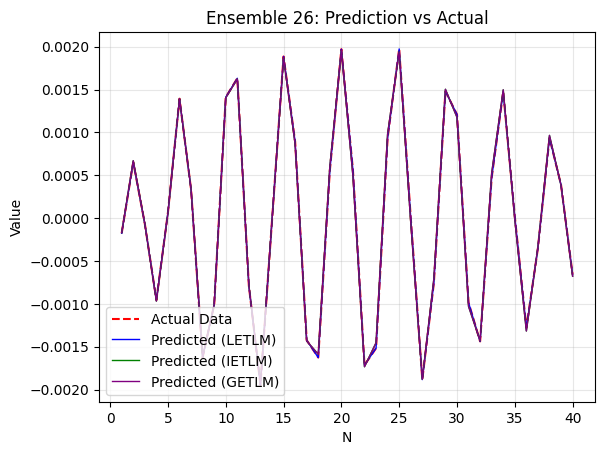

IETLM norm: tensor(0.0229)
LETLM norm: tensor(0.0005)
GETLM norm: tensor(0.0229)


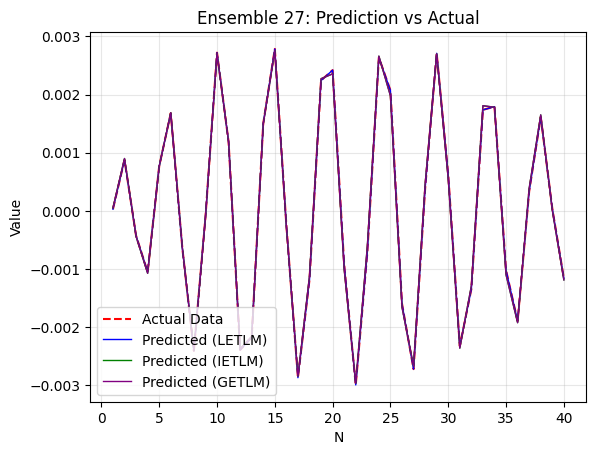

IETLM norm: tensor(0.0233)
LETLM norm: tensor(0.0006)
GETLM norm: tensor(0.0233)


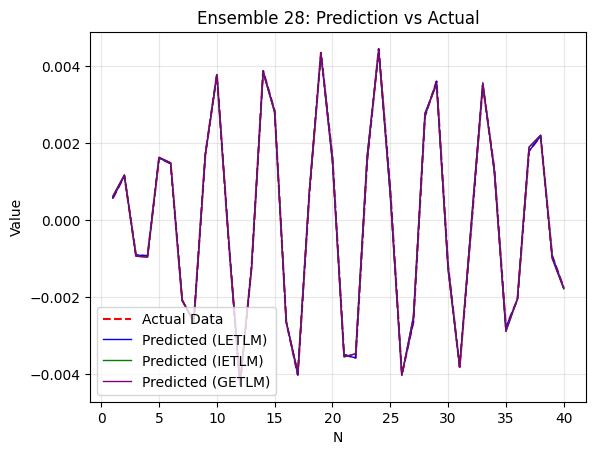

IETLM norm: tensor(0.0229)
LETLM norm: tensor(0.0008)
GETLM norm: tensor(0.0229)


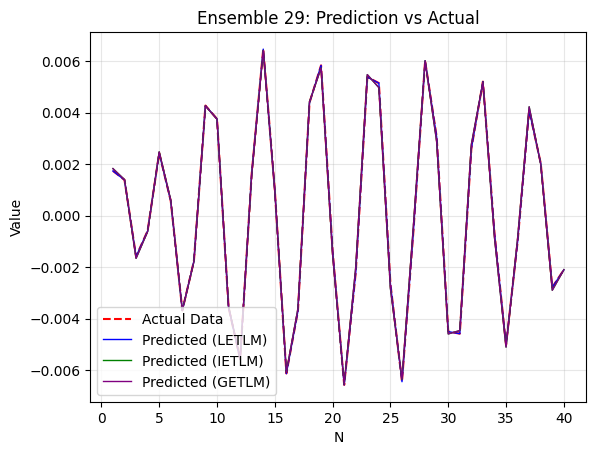

IETLM norm: tensor(0.0231)
LETLM norm: tensor(0.0011)
GETLM norm: tensor(0.0231)


<Figure size 640x480 with 0 Axes>

In [80]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []

# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0
GETLM_test_future = test_0
GETLM_test_current = test_final[starting_time]

letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
getlm_norm = L2_norm(GETLM_test_future, test_0)

LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
GETLM_norm.append(getlm_norm)

plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final)-3):
    test = test_final[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    # plt.imshow(ietlm,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("2D Tensor Heatmap")
    # plt.title("N_tilde")
    # plt.show()

    GETLM_test_past = GETLM_test_current
    GETLM_test_current = GETLM_test_future

    NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
    NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past



    IETLM_test = ietlm @ IETLM_test

    # We now need to calculate the L2 norm

    letlm_norm = L2_norm(LETLM_test, test)
    ietlm_norm = L2_norm(IETLM_test, test)
    getlm_norm = L2_norm(GETLM_test_future, test)
    LETLM_norm.append(letlm_norm)
    IETLM_norm.append(ietlm_norm)
    GETLM_norm.append(getlm_norm)


    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

    plt.title(f"Ensemble {i+1}: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    print('IETLM norm:', ietlm_norm)
    print('LETLM norm:', letlm_norm)
    print('GETLM norm:', getlm_norm)

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



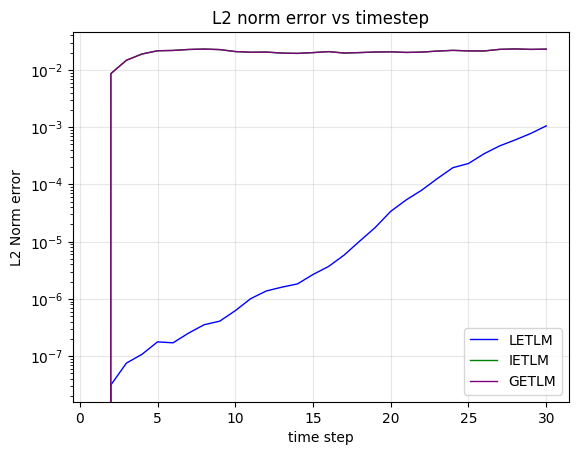

<Figure size 640x480 with 0 Axes>

In [81]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)
plt.yscale('log')
plt.plot(x_values_norm, LETLM_norm, label='LETLM', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_norm, label='IETLM', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_norm, label='GETLM', color='purple', linewidth=1)

plt.title("L2 norm error vs timestep")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()


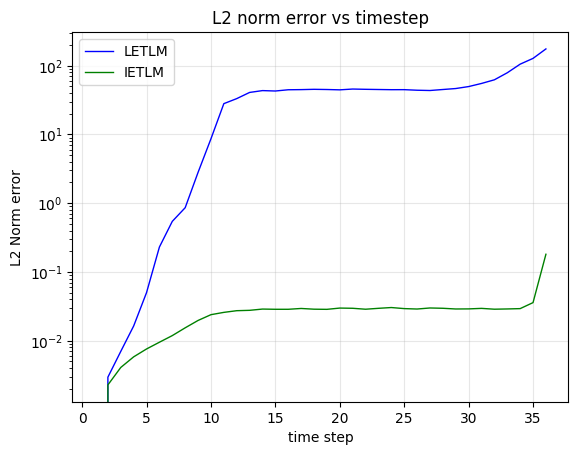

<Figure size 640x480 with 0 Axes>

In [50]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)
plt.yscale('log')
plt.plot(x_values_norm, LETLM_norm, label='LETLM', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_norm, label='IETLM', color='green', linewidth=1)
plt.title("L2 norm error vs timestep")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()

In [89]:
# We will also repeat this for Runge-Kutta 4

# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [90]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

100%|██████████| 999/999 [00:00<00:00, 14896.21it/s]


In [91]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_RK4 = [-2,-1,0,1]
stencil_members_current_RK4 = [-2,-1,0,1]
stencil_members_past_RK4 = [0]
stencil_members_large_RK4 = [stencil_members_future_RK4, stencil_members_current_RK4, stencil_members_past_RK4]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_RK4 = 9 + len(stencil_members_future_RK4) + len(stencil_members_current_RK4) + len(stencil_members_past_RK4)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final, Ensemble_final, Ensembles =  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_RK4, SD_pert, model, model_parameters, Test_pert, number_of_steps = 30)


In [92]:
IETLM_STENCIL_LARGE_RK4 = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE_RK4 = [[0],[-8,7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6]]

In [93]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 1 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_RK4, model_parameters, ensemble_size_RK4, k, plot = False)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_RK4)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_RK4)
    LETLMS.append(M_tilde)


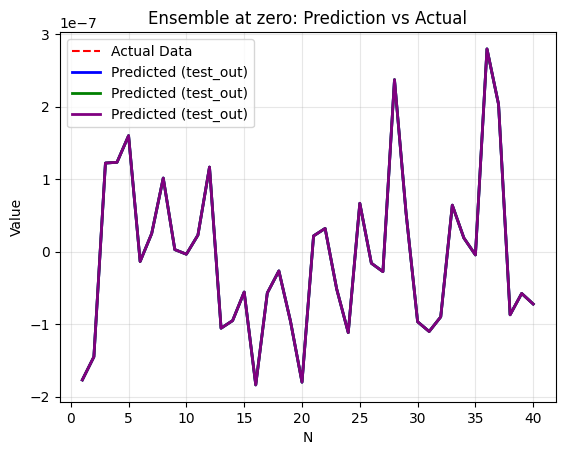

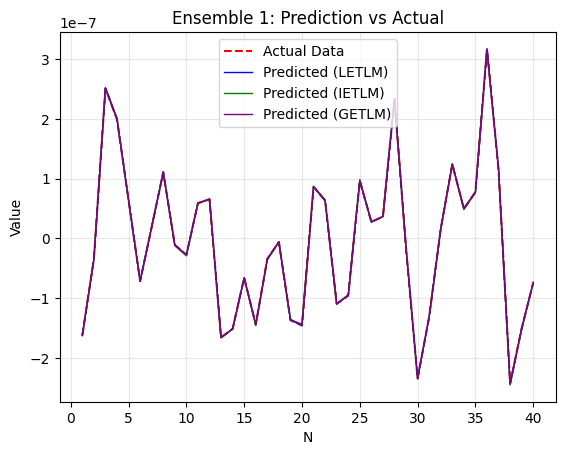

IETLM norm: tensor(0.0084)
LETLM norm: tensor(2.8875e-08)
GETLM norm: tensor(0.0034)


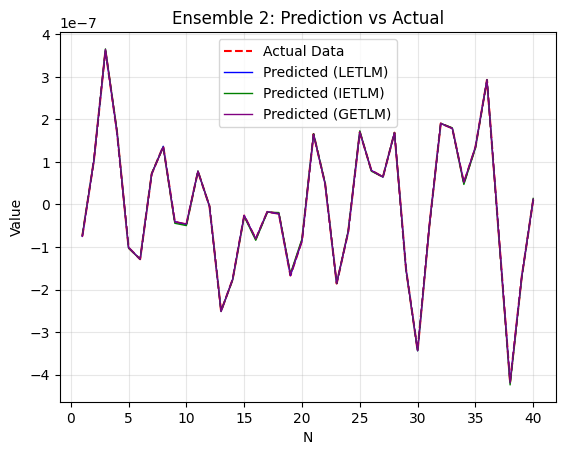

IETLM norm: tensor(0.0145)
LETLM norm: tensor(6.0885e-08)
GETLM norm: tensor(0.0054)


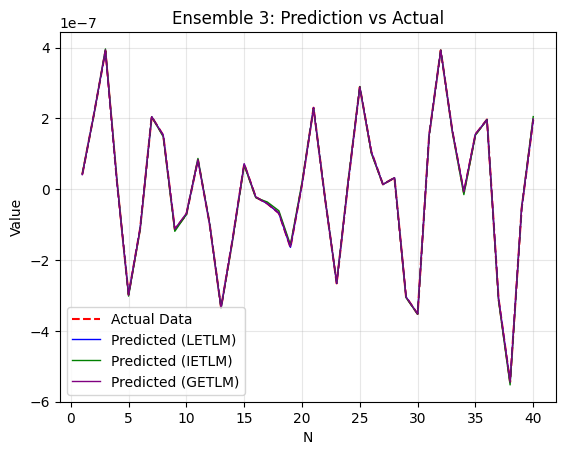

IETLM norm: tensor(0.0193)
LETLM norm: tensor(8.4802e-08)
GETLM norm: tensor(0.0069)


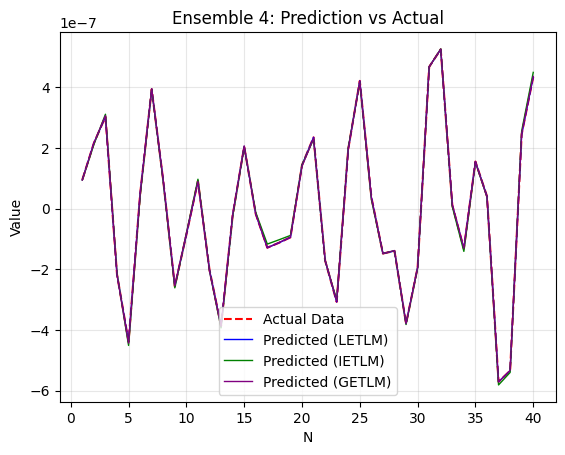

IETLM norm: tensor(0.0223)
LETLM norm: tensor(1.0752e-07)
GETLM norm: tensor(0.0075)


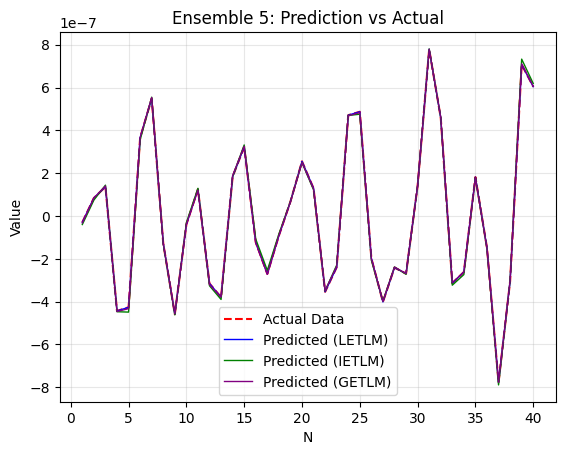

IETLM norm: tensor(0.0245)
LETLM norm: tensor(1.8625e-07)
GETLM norm: tensor(0.0083)


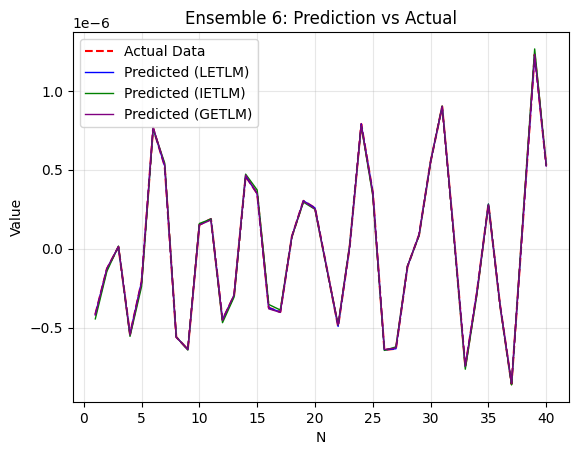

IETLM norm: tensor(0.0266)
LETLM norm: tensor(2.7421e-07)
GETLM norm: tensor(0.0093)


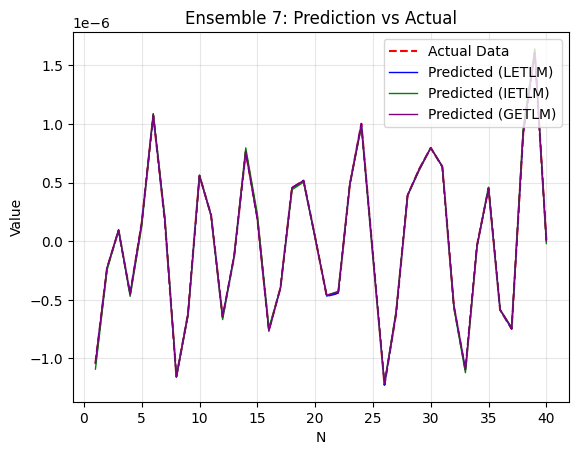

IETLM norm: tensor(0.0288)
LETLM norm: tensor(3.9113e-07)
GETLM norm: tensor(0.0097)


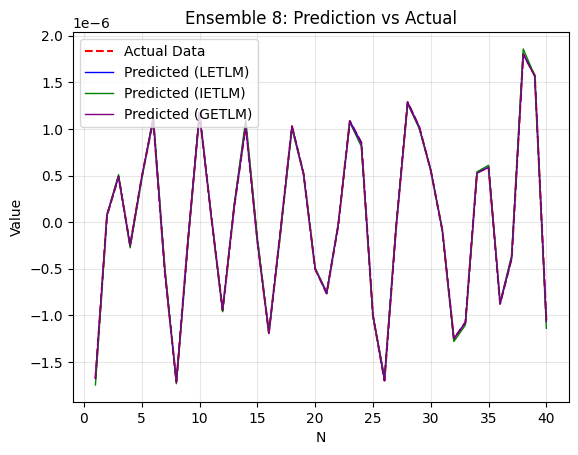

IETLM norm: tensor(0.0311)
LETLM norm: tensor(6.3475e-07)
GETLM norm: tensor(0.0099)


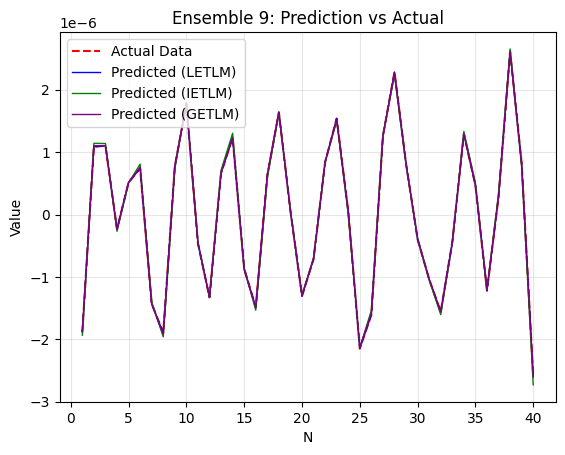

IETLM norm: tensor(0.0318)
LETLM norm: tensor(9.1339e-07)
GETLM norm: tensor(0.0100)


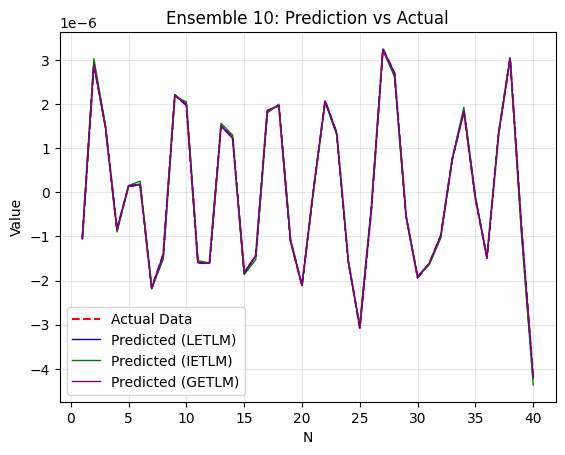

IETLM norm: tensor(0.0318)
LETLM norm: tensor(1.2313e-06)
GETLM norm: tensor(0.0104)


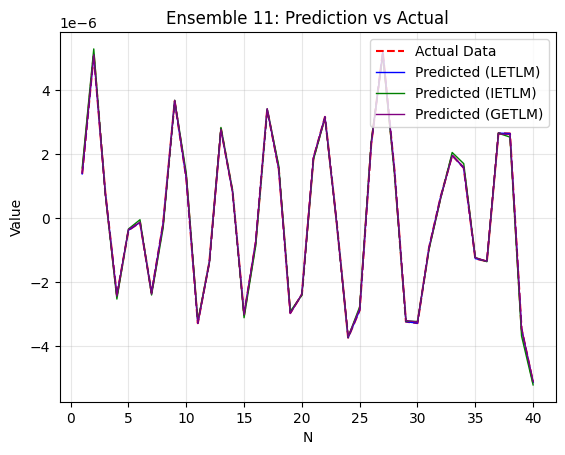

IETLM norm: tensor(0.0331)
LETLM norm: tensor(1.8165e-06)
GETLM norm: tensor(0.0108)


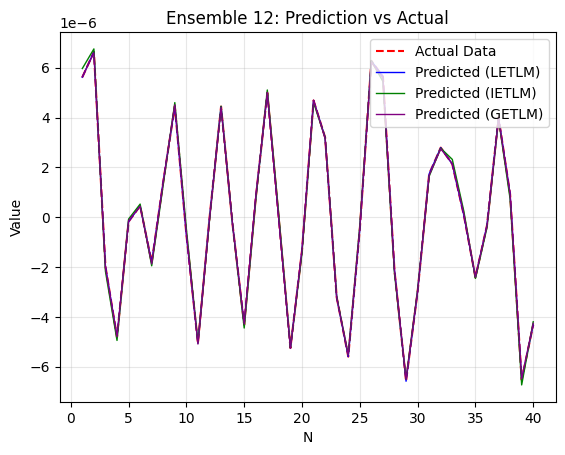

IETLM norm: tensor(0.0353)
LETLM norm: tensor(2.5749e-06)
GETLM norm: tensor(0.0116)


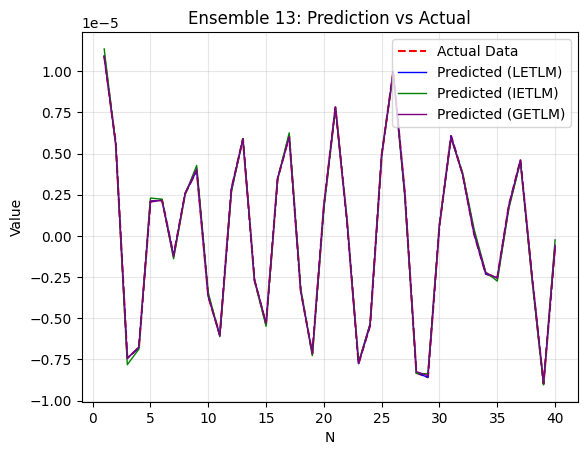

IETLM norm: tensor(0.0332)
LETLM norm: tensor(3.5966e-06)
GETLM norm: tensor(0.0111)


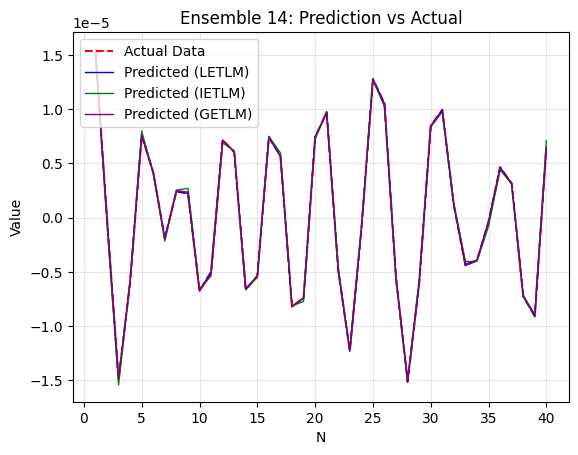

IETLM norm: tensor(0.0327)
LETLM norm: tensor(6.4367e-06)
GETLM norm: tensor(0.0112)


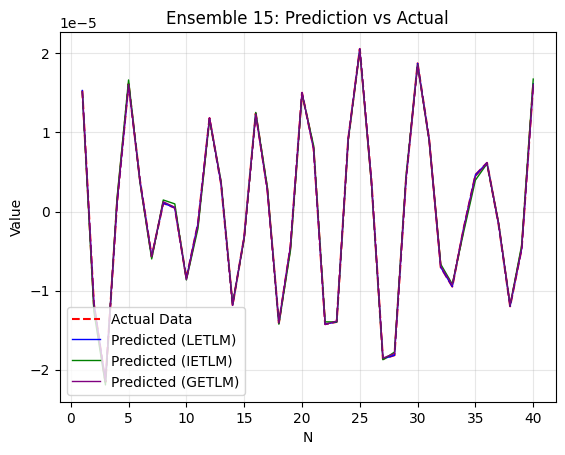

IETLM norm: tensor(0.0346)
LETLM norm: tensor(7.7335e-06)
GETLM norm: tensor(0.0116)


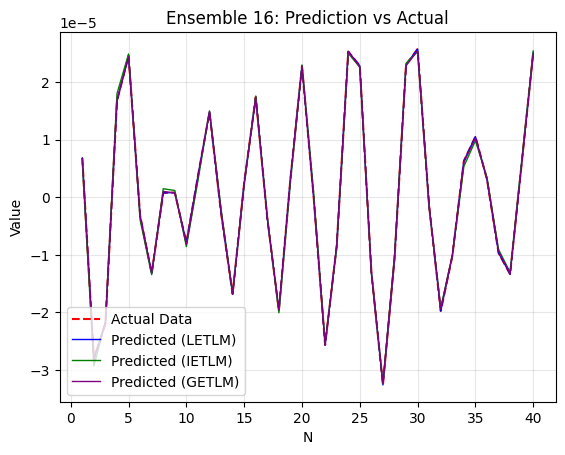

IETLM norm: tensor(0.0342)
LETLM norm: tensor(9.9483e-06)
GETLM norm: tensor(0.0118)


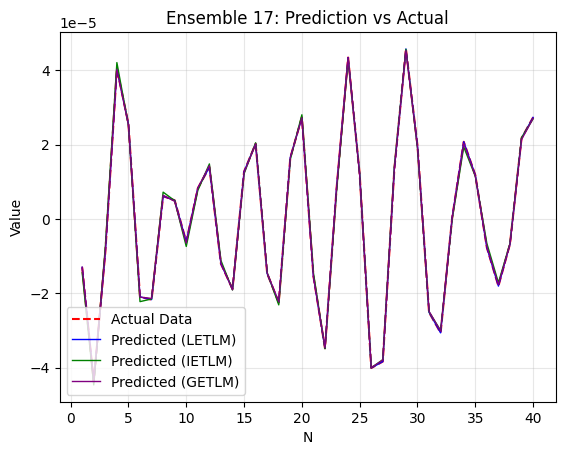

IETLM norm: tensor(0.0313)
LETLM norm: tensor(1.6149e-05)
GETLM norm: tensor(0.0115)


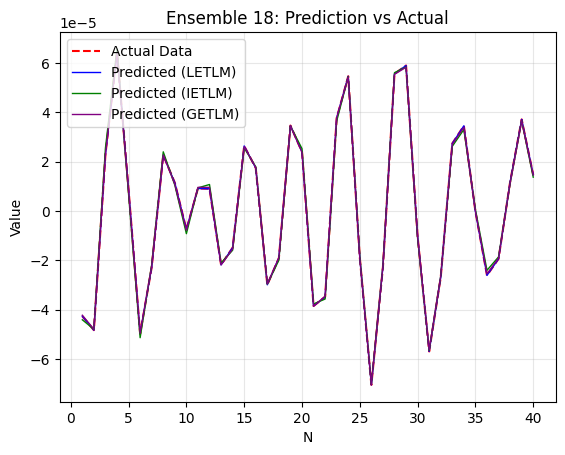

IETLM norm: tensor(0.0322)
LETLM norm: tensor(2.0395e-05)
GETLM norm: tensor(0.0115)


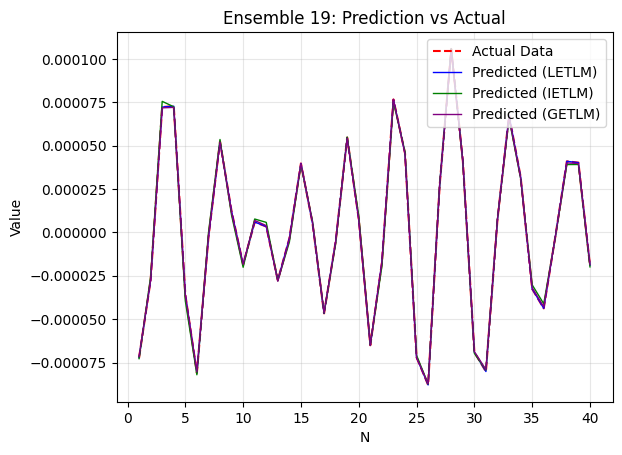

IETLM norm: tensor(0.0316)
LETLM norm: tensor(2.9833e-05)
GETLM norm: tensor(0.0122)


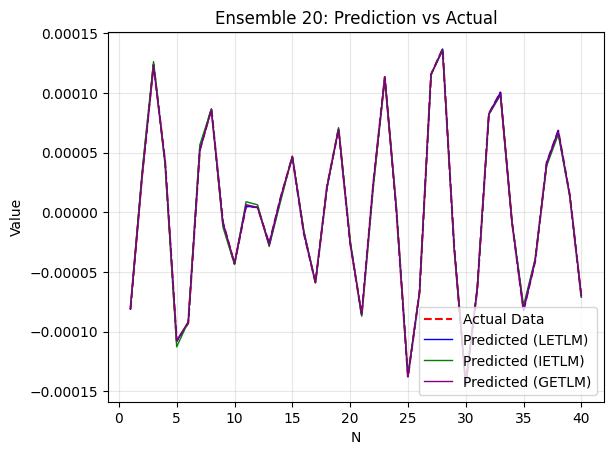

IETLM norm: tensor(0.0301)
LETLM norm: tensor(5.6030e-05)
GETLM norm: tensor(0.0123)


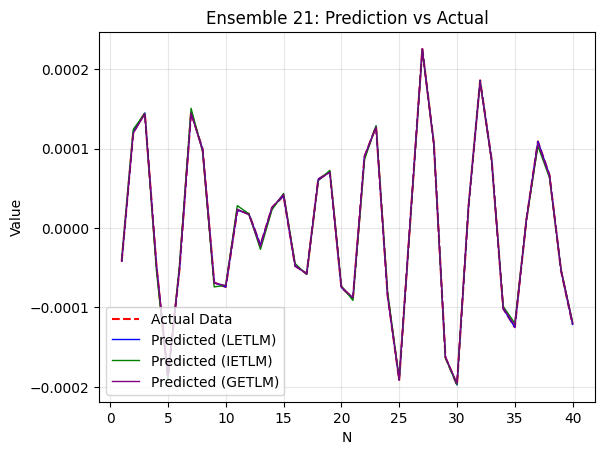

IETLM norm: tensor(0.0301)
LETLM norm: tensor(7.5480e-05)
GETLM norm: tensor(0.0120)


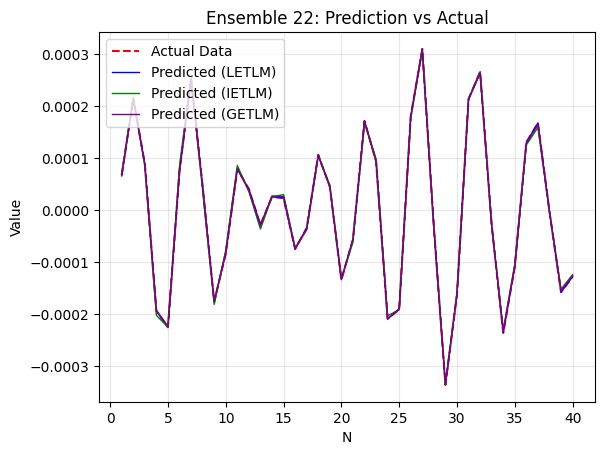

IETLM norm: tensor(0.0290)
LETLM norm: tensor(0.0001)
GETLM norm: tensor(0.0123)


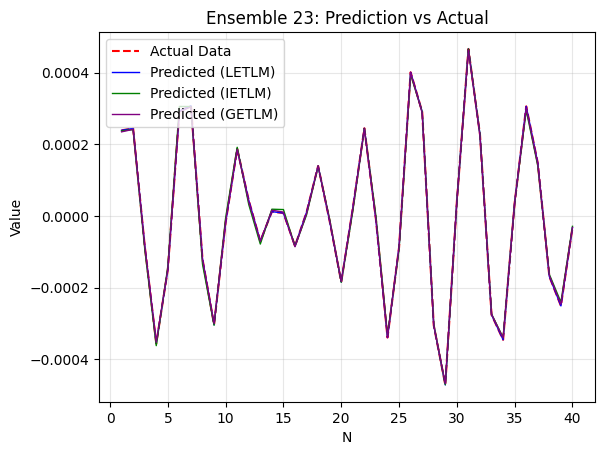

IETLM norm: tensor(0.0290)
LETLM norm: tensor(0.0002)
GETLM norm: tensor(0.0130)


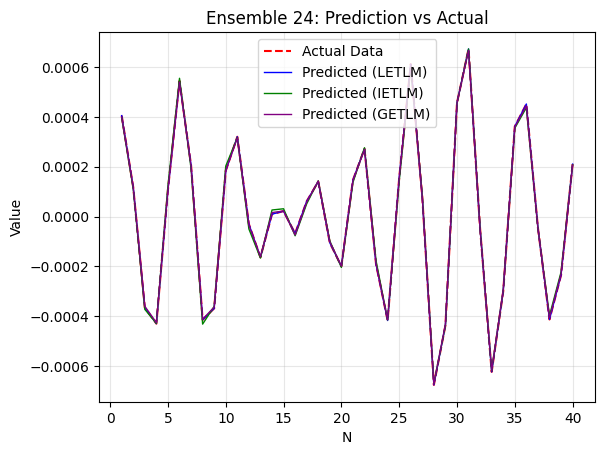

IETLM norm: tensor(0.0288)
LETLM norm: tensor(0.0003)
GETLM norm: tensor(0.0128)


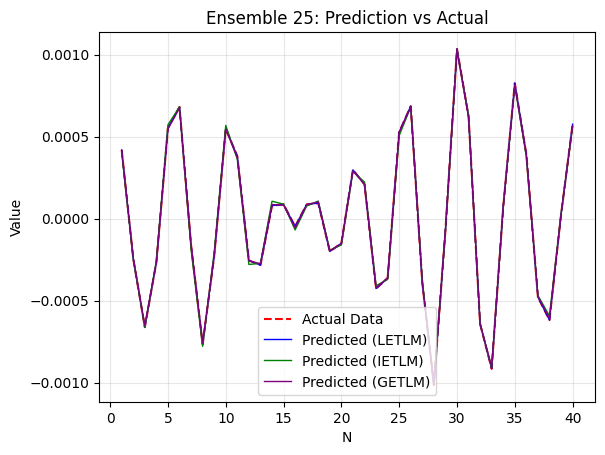

IETLM norm: tensor(0.0286)
LETLM norm: tensor(0.0004)
GETLM norm: tensor(0.0128)


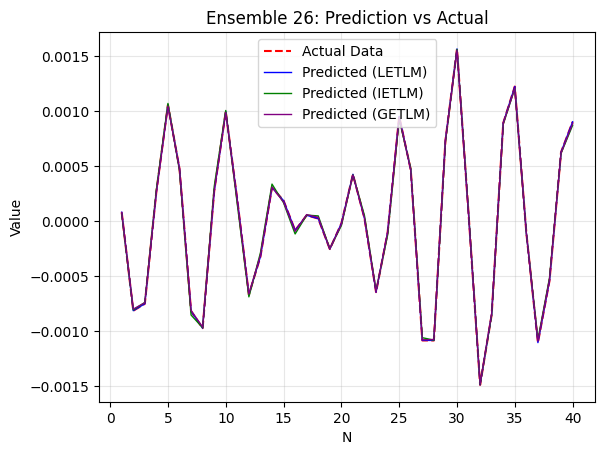

IETLM norm: tensor(0.0289)
LETLM norm: tensor(0.0007)
GETLM norm: tensor(0.0134)


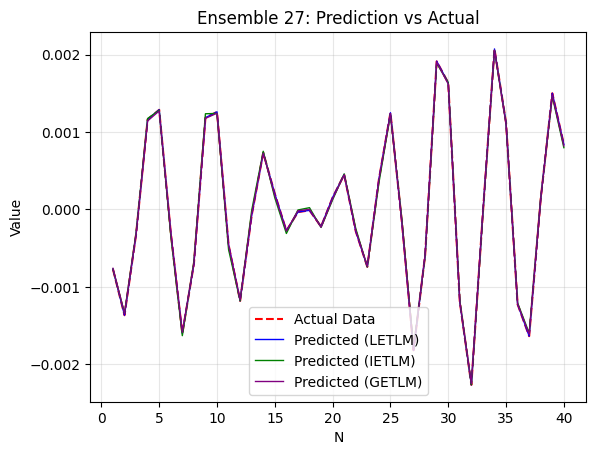

IETLM norm: tensor(0.0288)
LETLM norm: tensor(0.0009)
GETLM norm: tensor(0.0135)


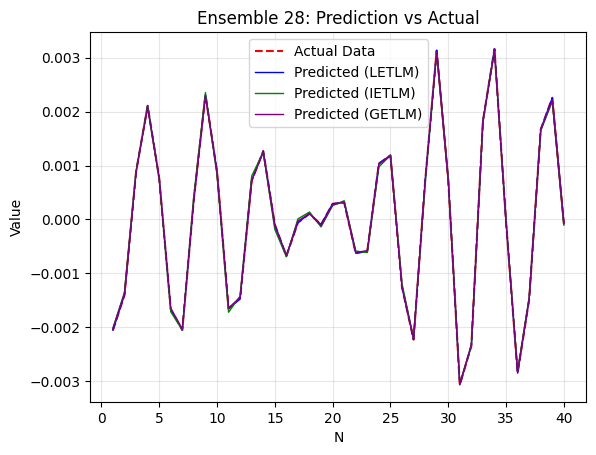

IETLM norm: tensor(0.0290)
LETLM norm: tensor(0.0013)
GETLM norm: tensor(0.0135)


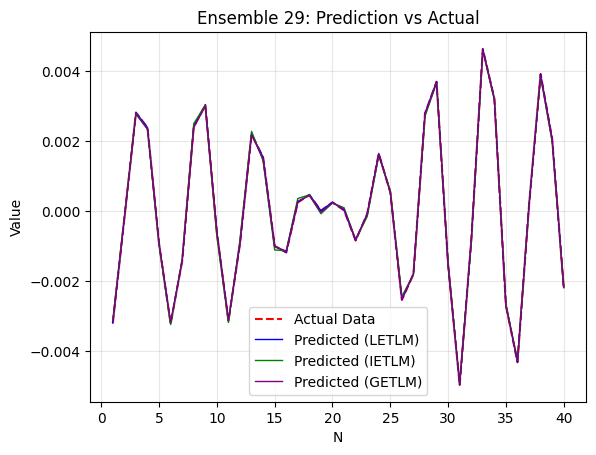

IETLM norm: tensor(0.0285)
LETLM norm: tensor(0.0019)
GETLM norm: tensor(0.0137)


<Figure size 640x480 with 0 Axes>

In [94]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []

# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0
GETLM_test_future = test_0
GETLM_test_current = test_final[starting_time]

letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
getlm_norm = L2_norm(GETLM_test_future, test_0)

LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
GETLM_norm.append(getlm_norm)

plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final)-3):
    test = test_final[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    # plt.imshow(ietlm,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("2D Tensor Heatmap")
    # plt.title("N_tilde")
    # plt.show()

    GETLM_test_past = GETLM_test_current
    GETLM_test_current = GETLM_test_future

    NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
    NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past



    IETLM_test = ietlm @ IETLM_test

    # We now need to calculate the L2 norm

    letlm_norm = L2_norm(LETLM_test, test)
    ietlm_norm = L2_norm(IETLM_test, test)
    getlm_norm = L2_norm(GETLM_test_future, test)
    LETLM_norm.append(letlm_norm)
    IETLM_norm.append(ietlm_norm)
    GETLM_norm.append(getlm_norm)


    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

    plt.title(f"Ensemble {i+1}: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    print('IETLM norm:', ietlm_norm)
    print('LETLM norm:', letlm_norm)
    print('GETLM norm:', getlm_norm)

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



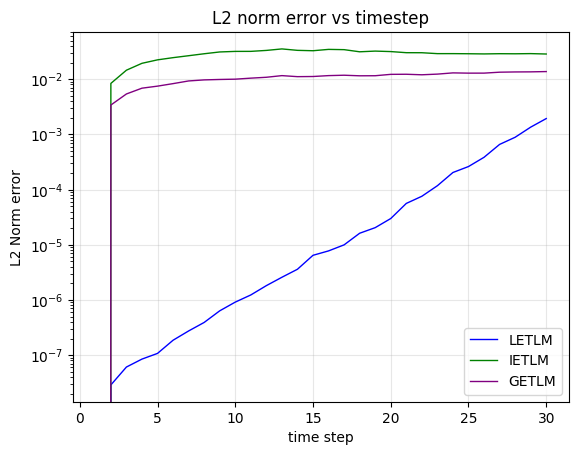

<Figure size 640x480 with 0 Axes>

In [95]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)
plt.yscale('log')
plt.plot(x_values_norm, LETLM_norm, label='LETLM', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_norm, label='IETLM', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_norm, label='GETLM', color='purple', linewidth=1)
plt.title("L2 norm error vs timestep")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()


In [96]:
# We will also repeat this for Leapfrog
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.LF_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [97]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

100%|██████████| 999/999 [00:00<00:00, 32720.92it/s]


In [103]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_LF = [-2,-1,0,1]
stencil_members_current_LF = [-2,-1,0,1]
stencil_members_past_LF = [0]
stencil_members_large_LF = [stencil_members_future_LF, stencil_members_current_LF, stencil_members_past_LF]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_LF = 9 + len(stencil_members_future_LF) + len(stencil_members_current_LF) + len(stencil_members_past_LF)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final, Ensemble_final, Ensembles =  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_LF, SD_pert, model, model_parameters, Test_pert, number_of_steps = 20)


In [104]:
IETLM_STENCIL_LARGE_RK4 = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE_RK4 = [[0],[-8,7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6]]

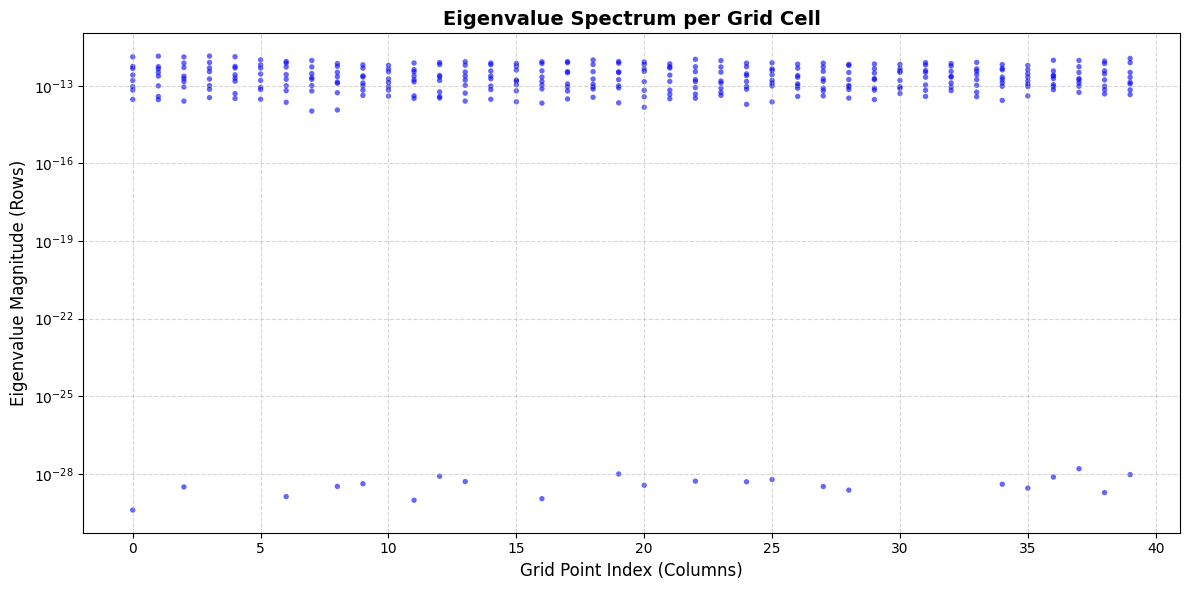

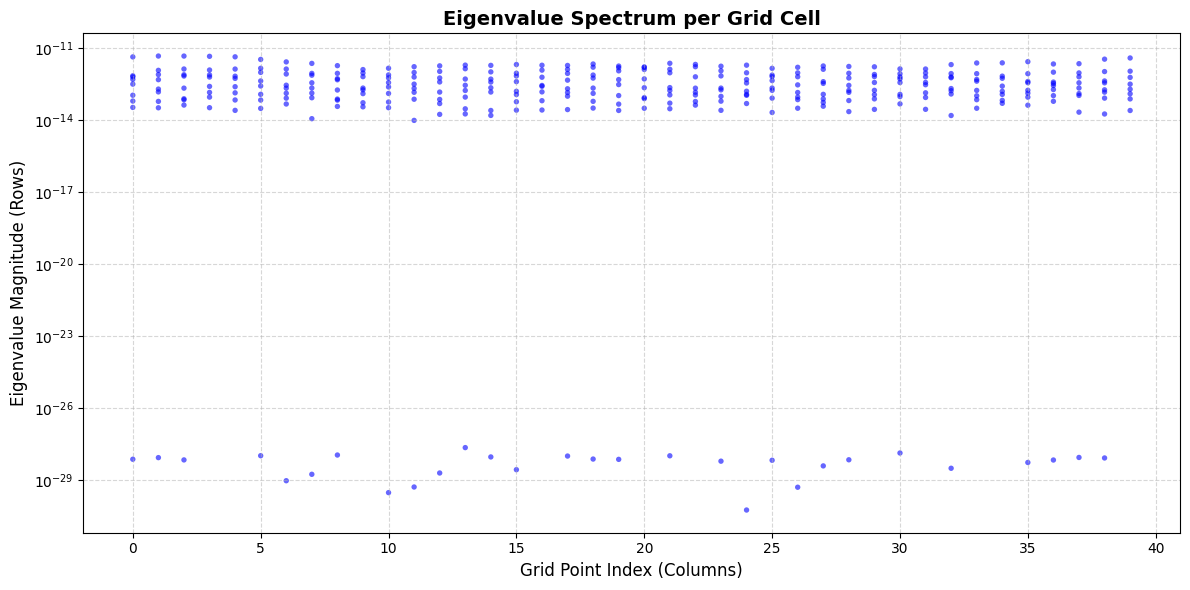

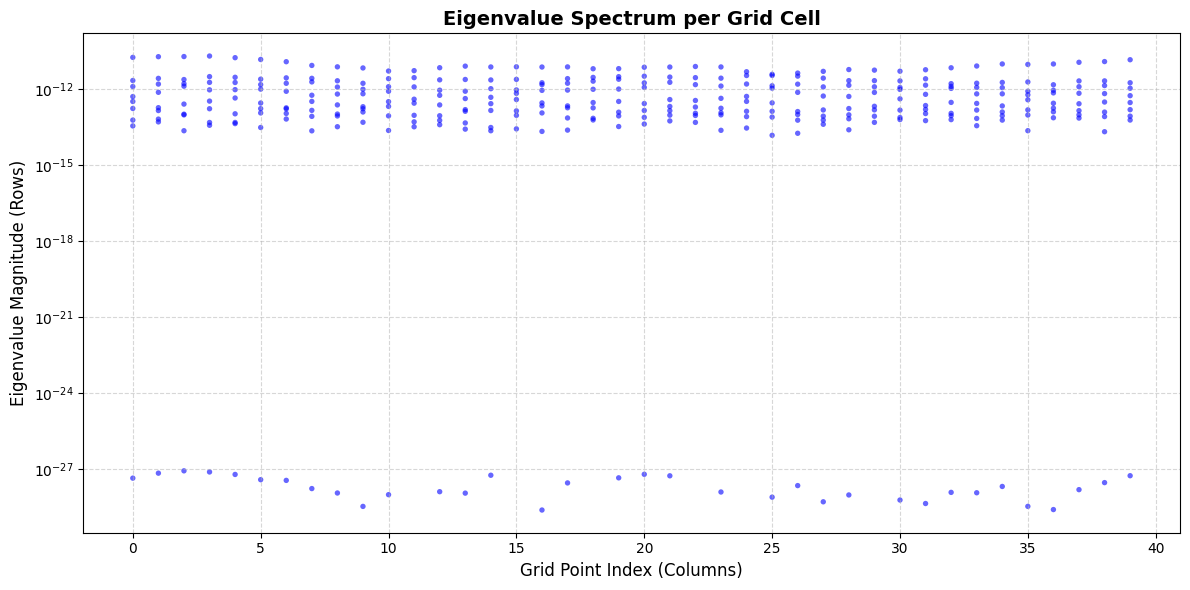

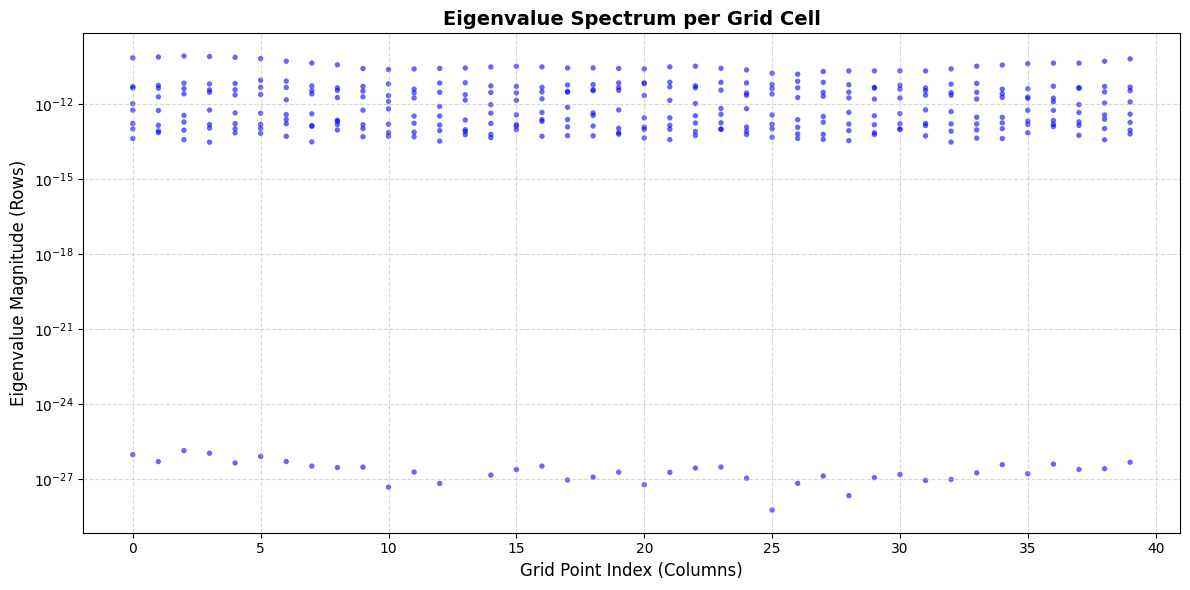

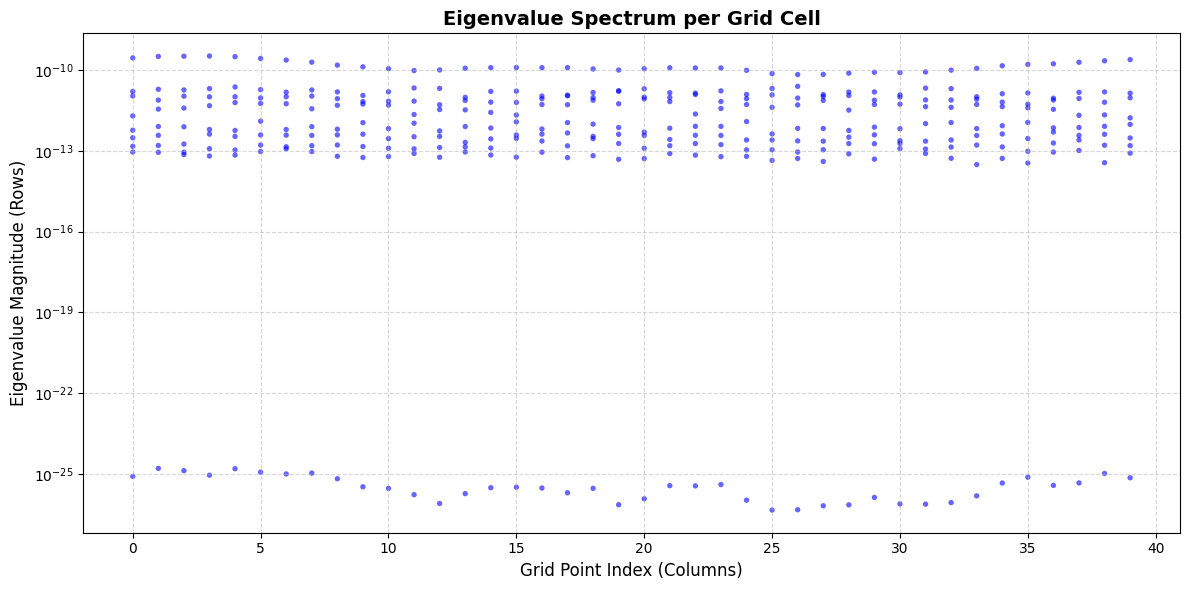

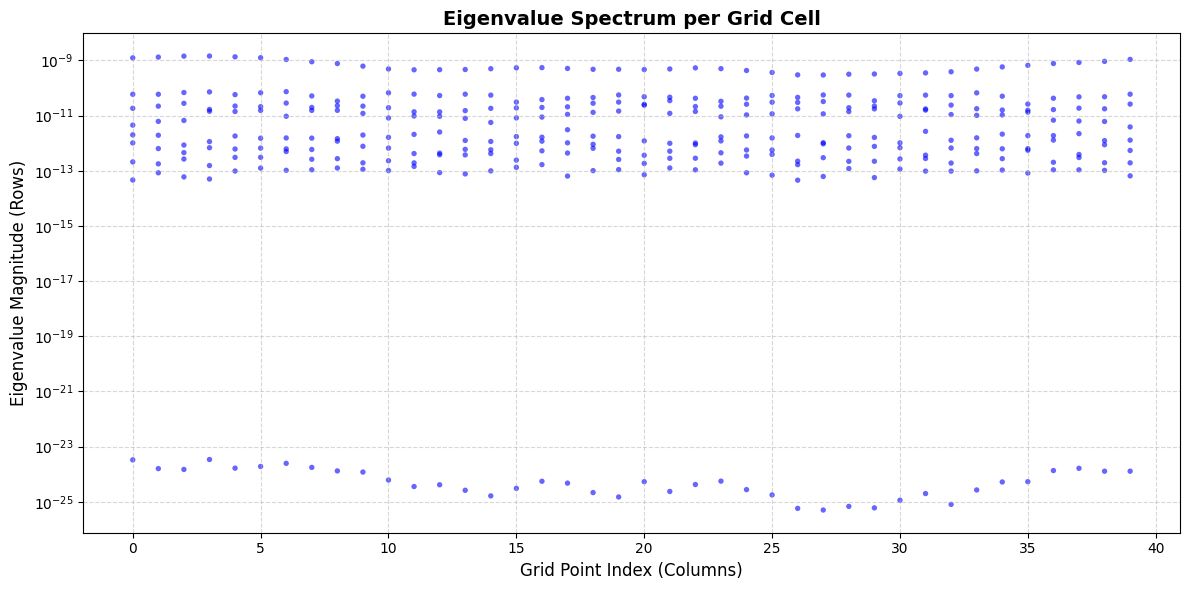

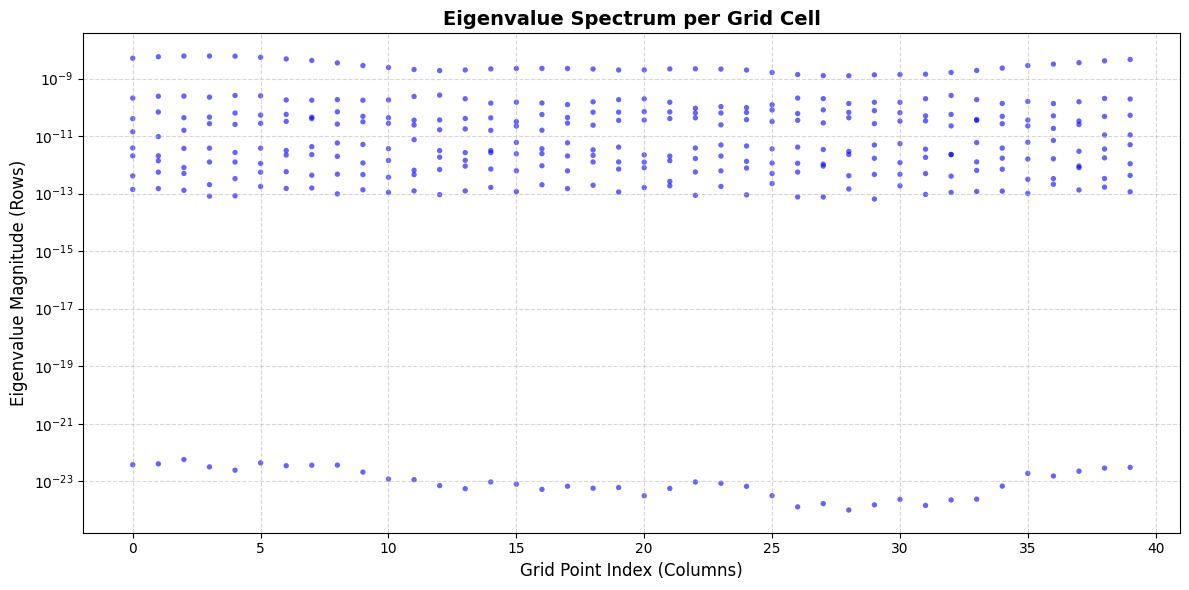

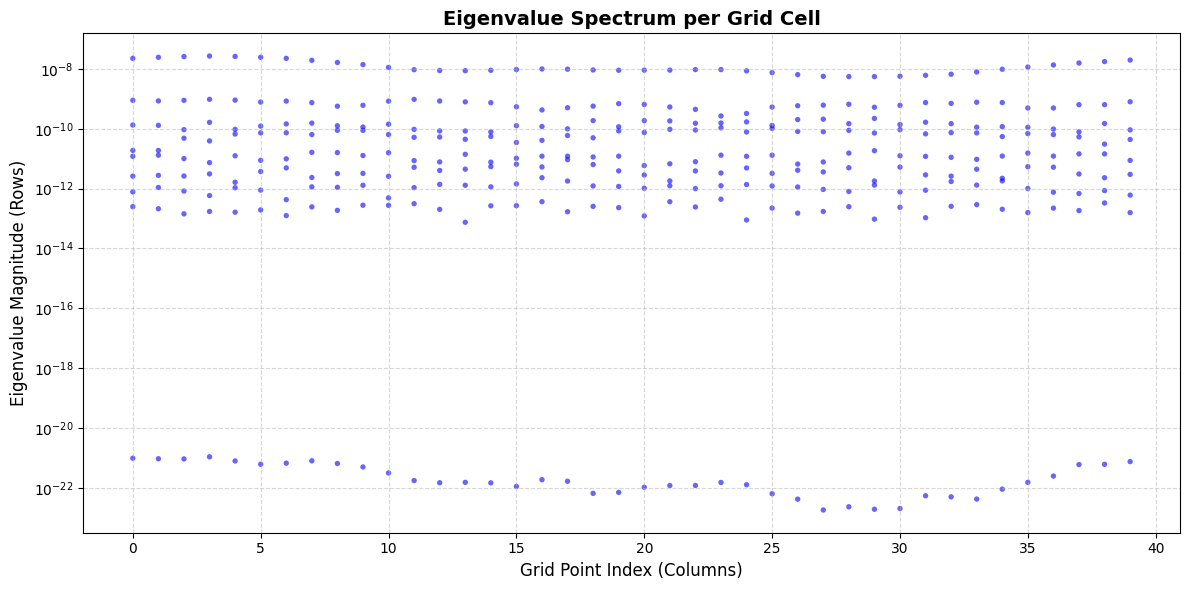

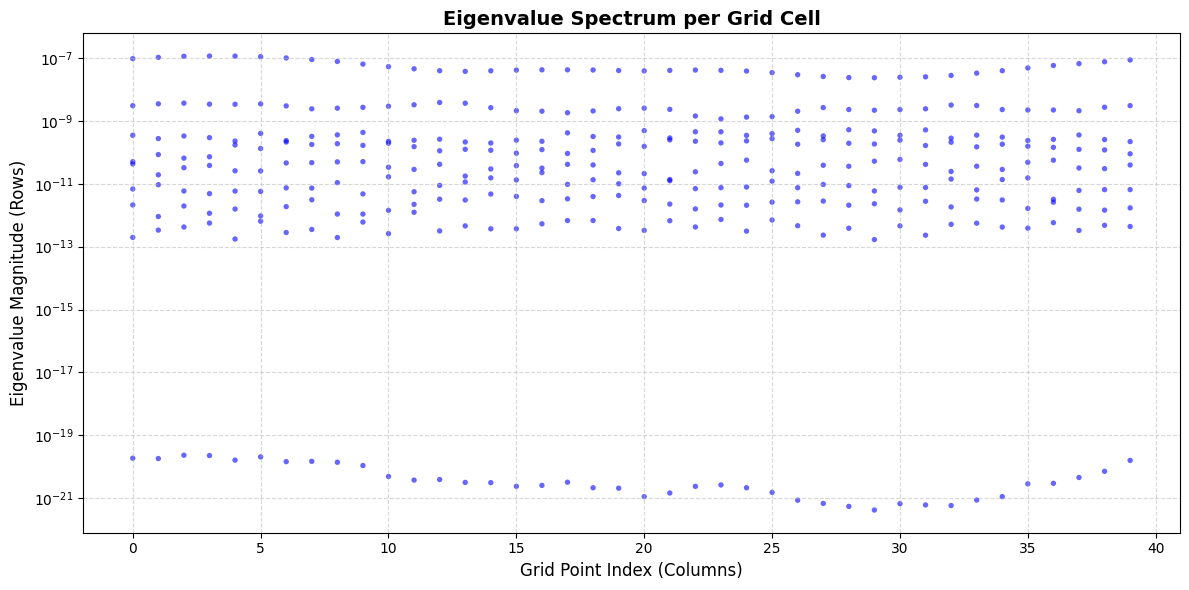

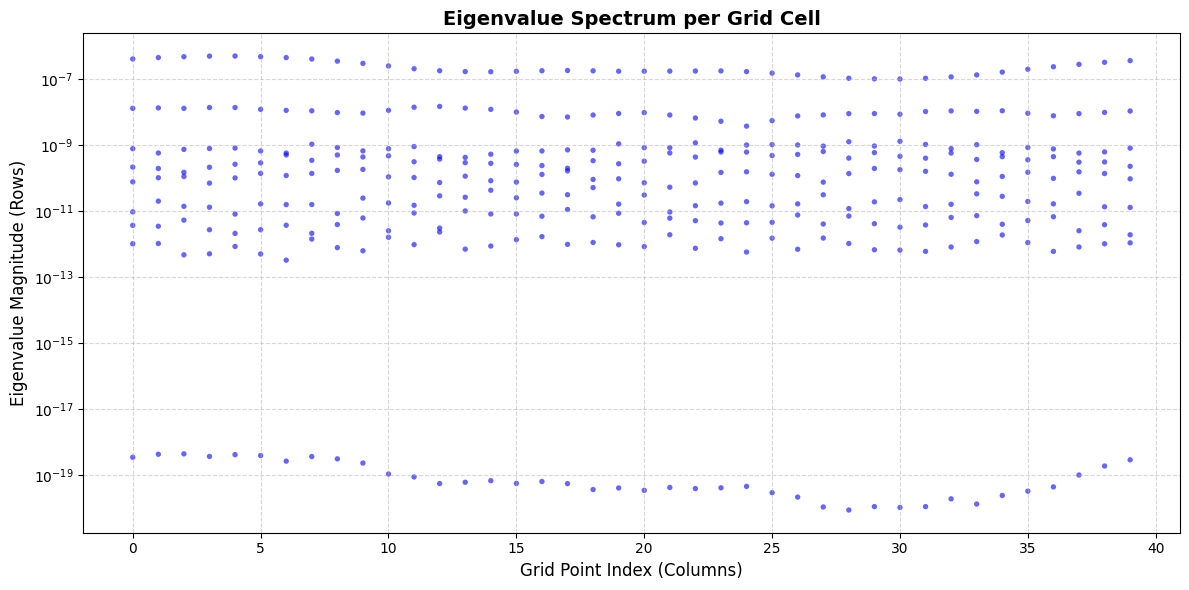

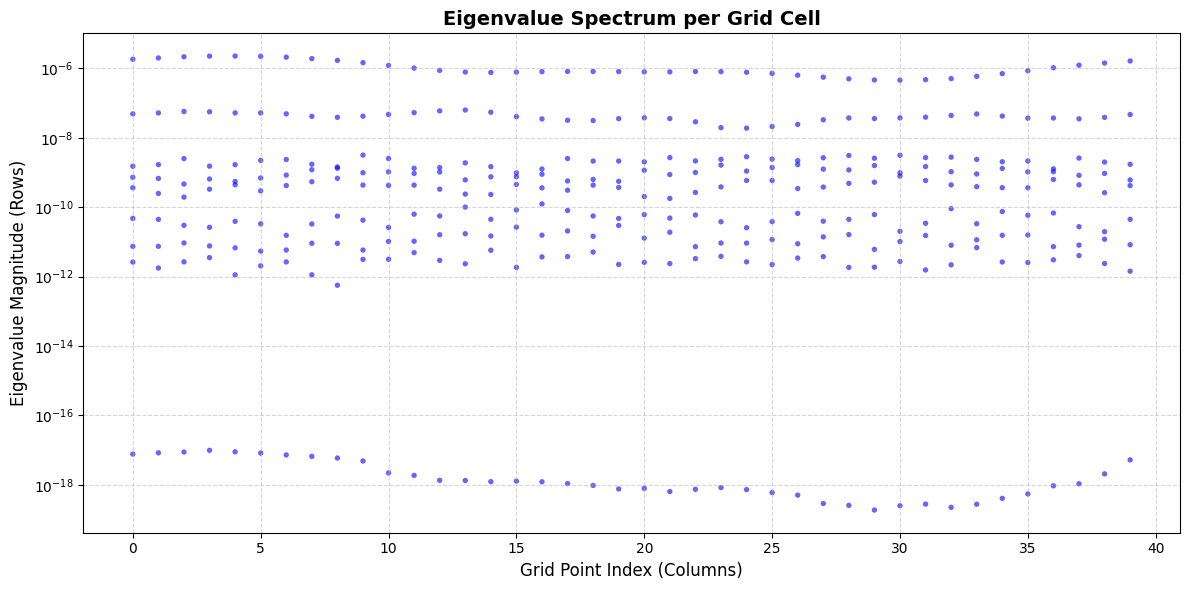

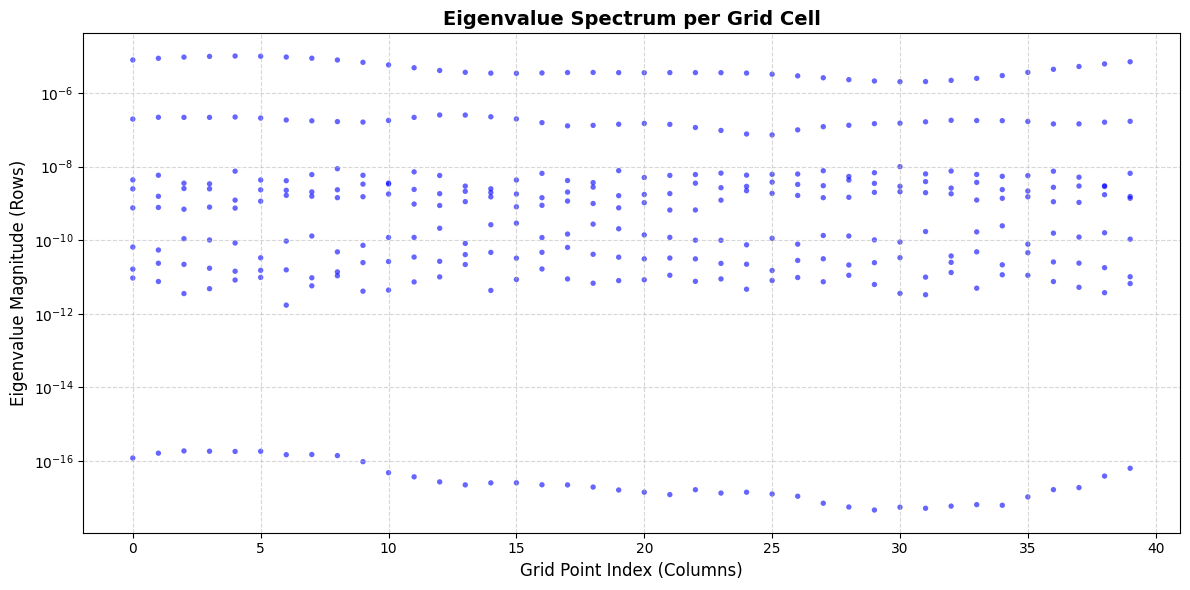

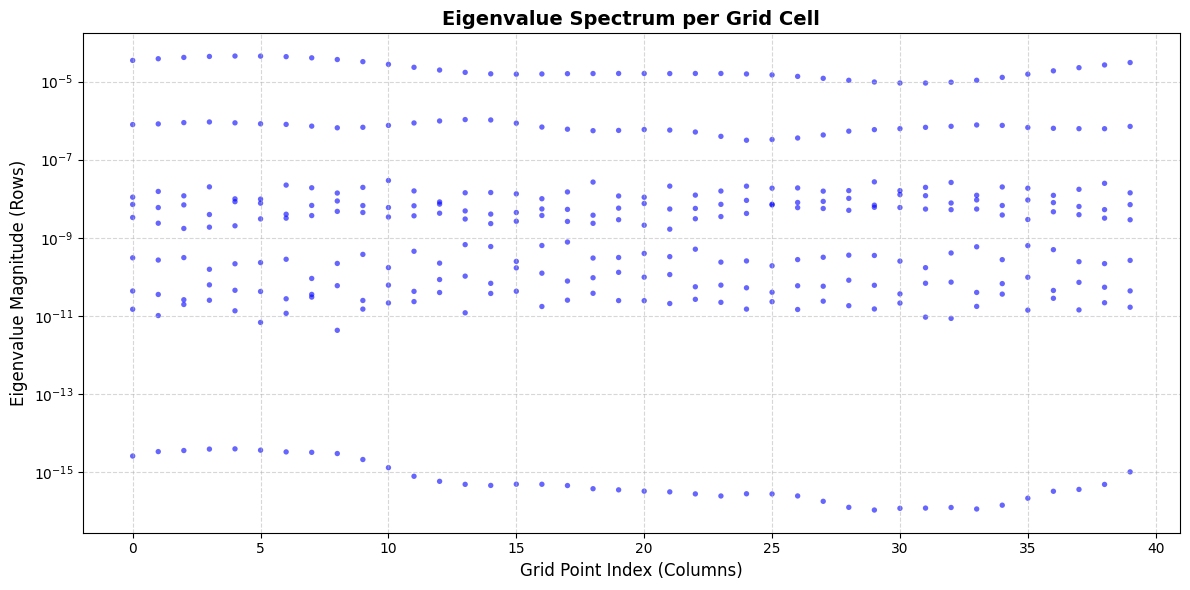

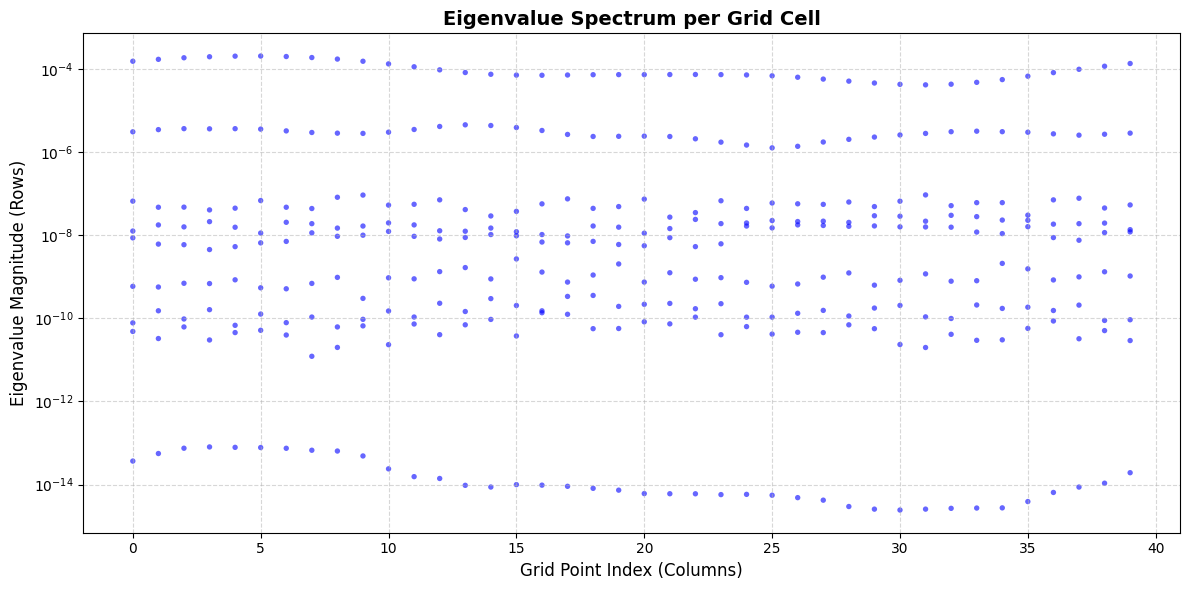

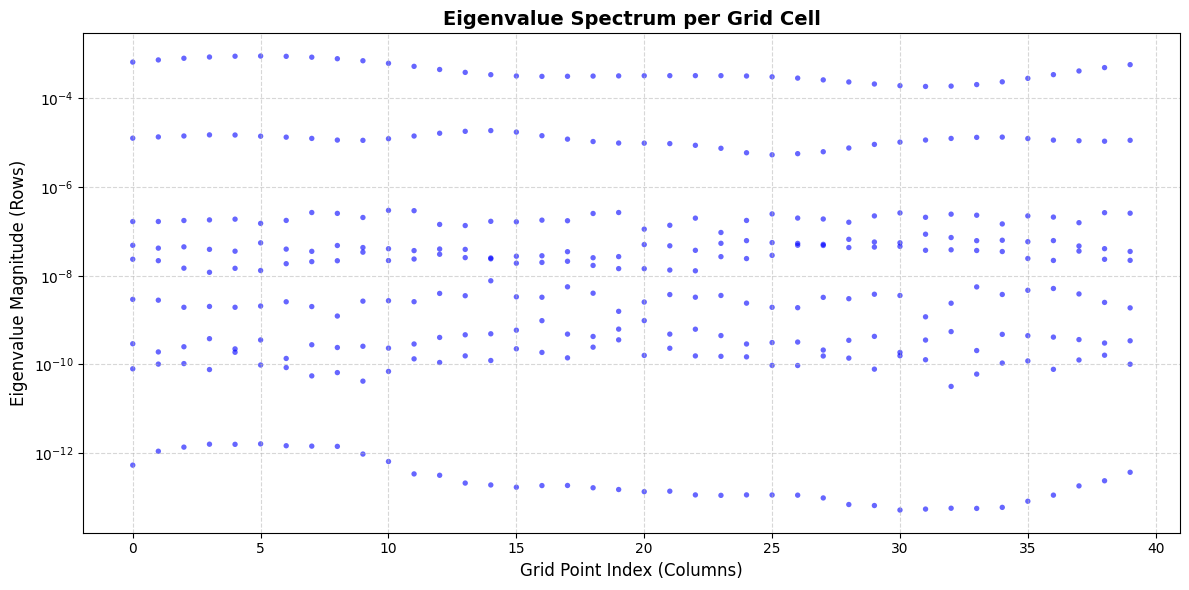

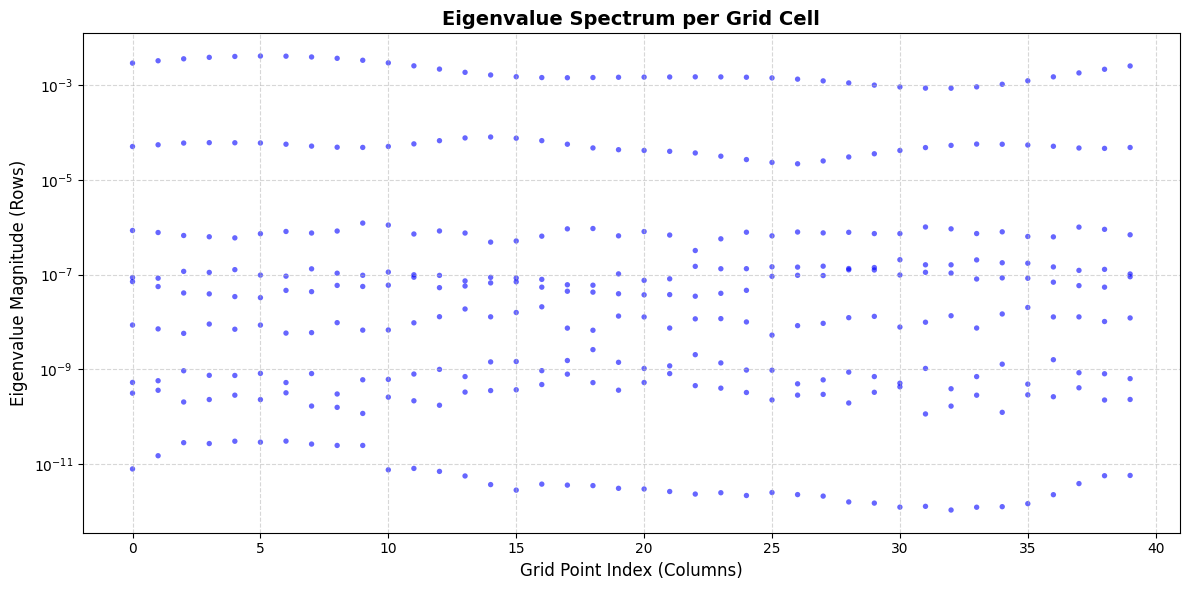

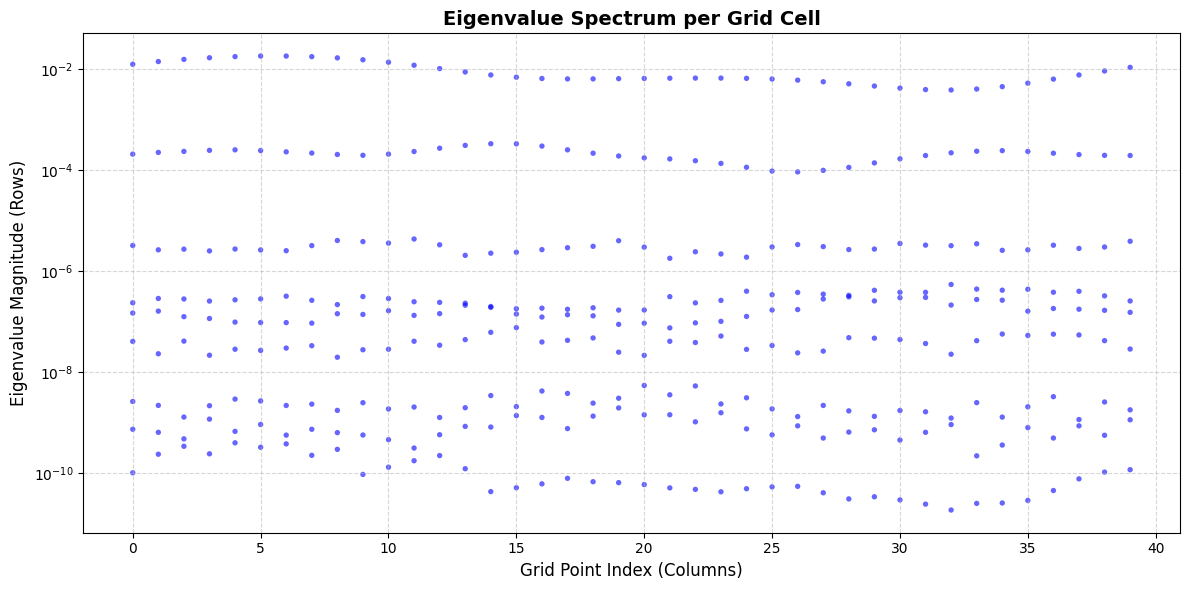

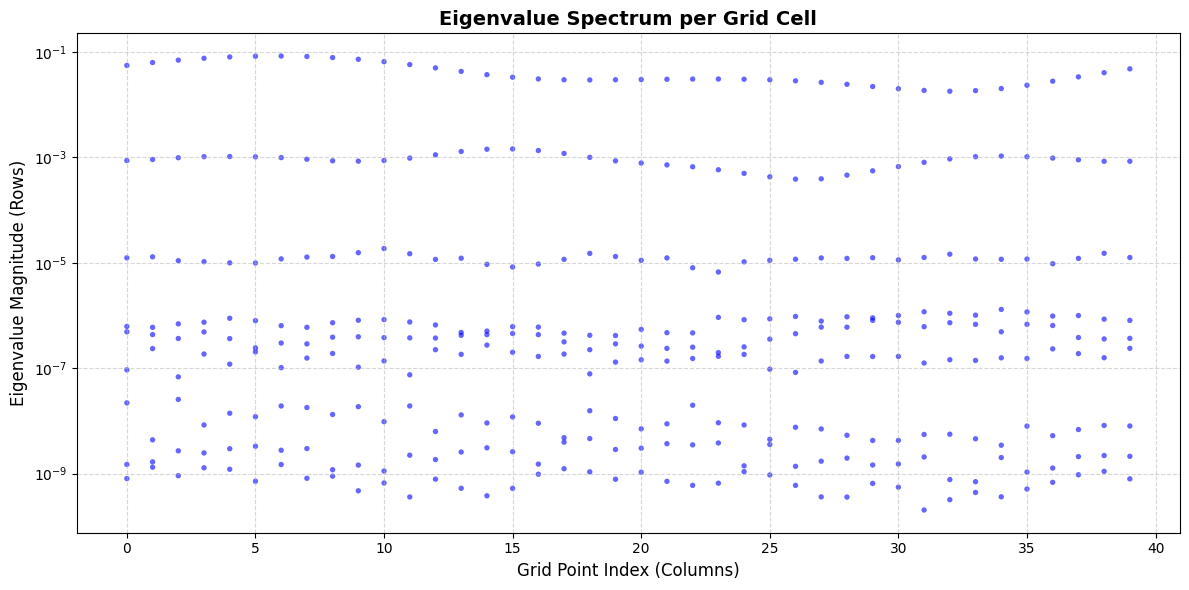

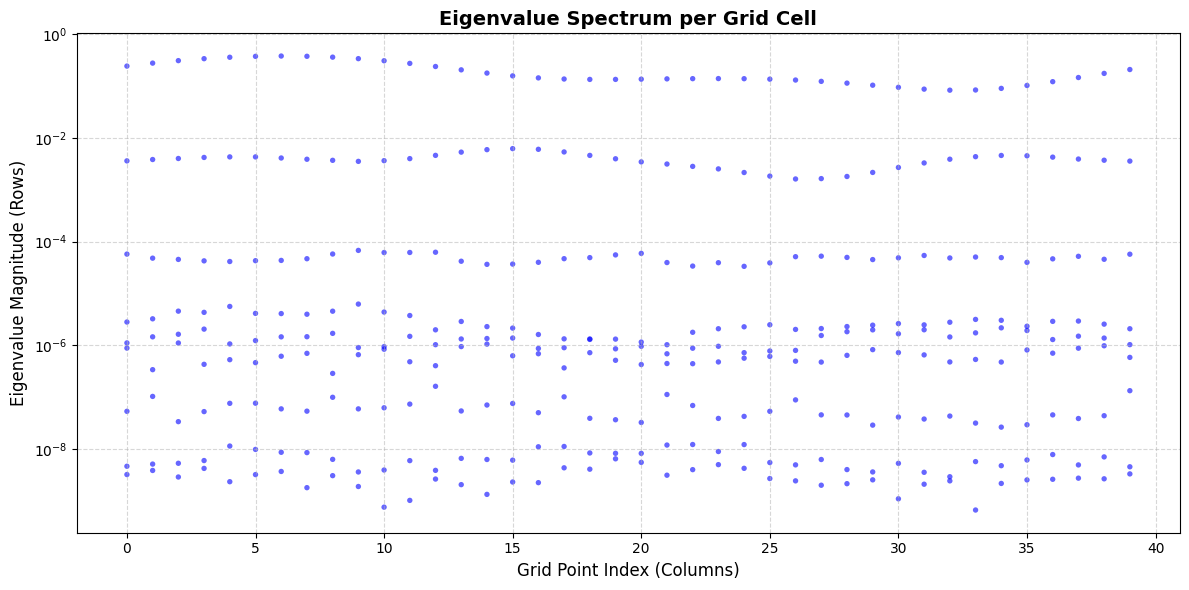

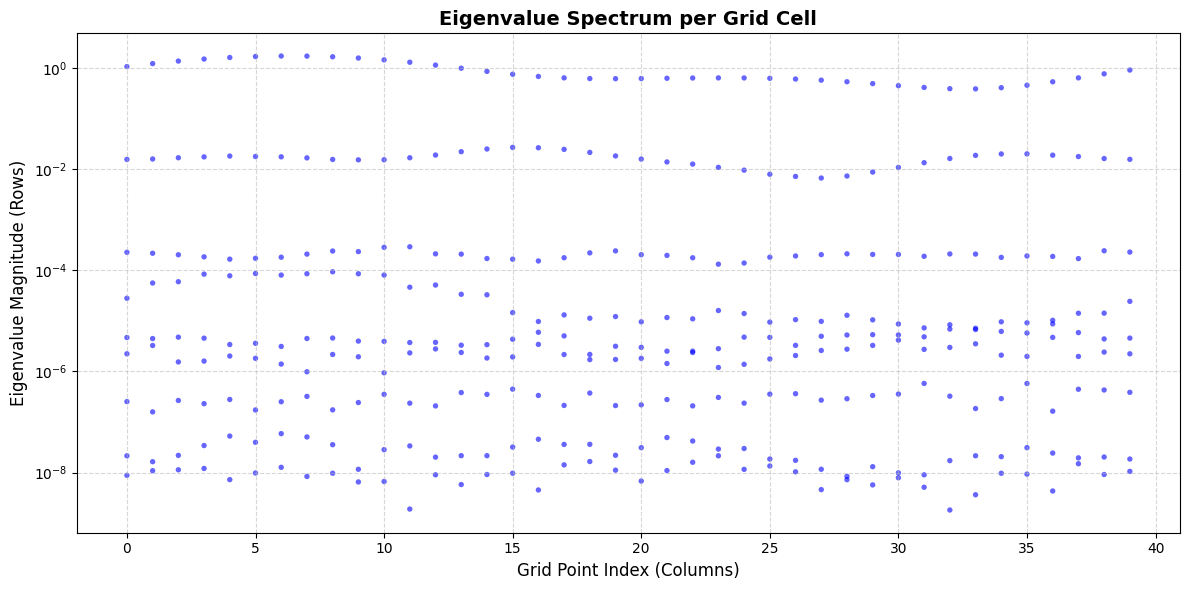

In [112]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 1 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_LF, model_parameters, ensemble_size_LF, k, plot = True)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_LF)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_LF)
    LETLMS.append(M_tilde)


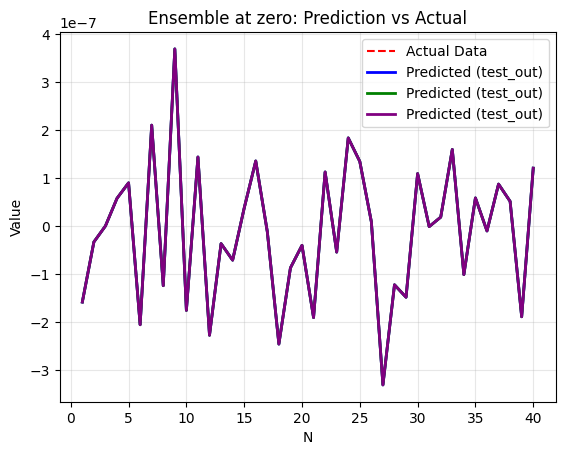

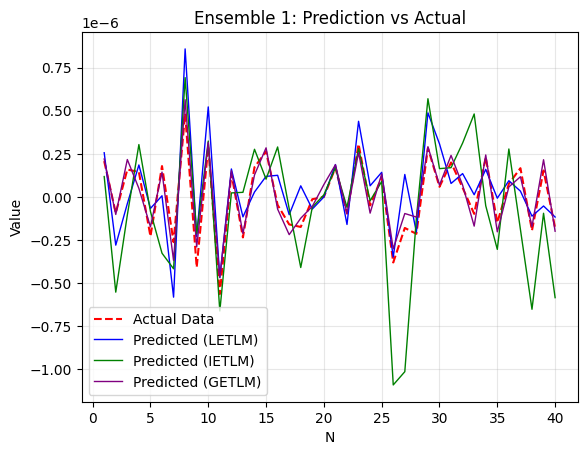

IETLM norm: tensor(1.1592)
LETLM norm: tensor(0.6801)
GETLM norm: tensor(0.2398)


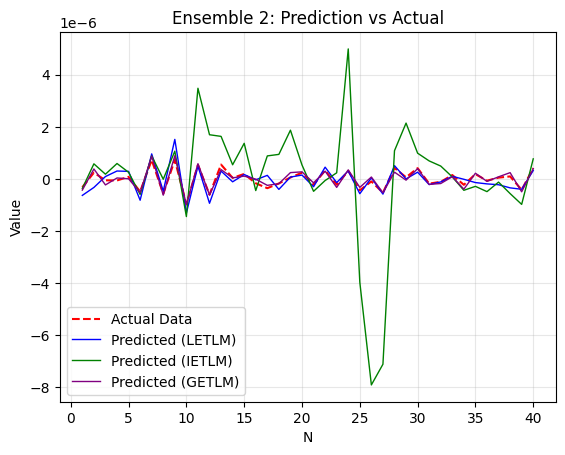

IETLM norm: tensor(3.9055)
LETLM norm: tensor(0.6301)
GETLM norm: tensor(0.2735)


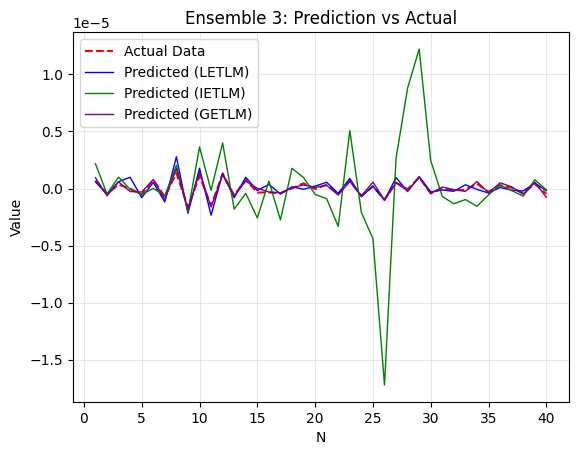

IETLM norm: tensor(3.9192)
LETLM norm: tensor(0.5514)
GETLM norm: tensor(0.2689)


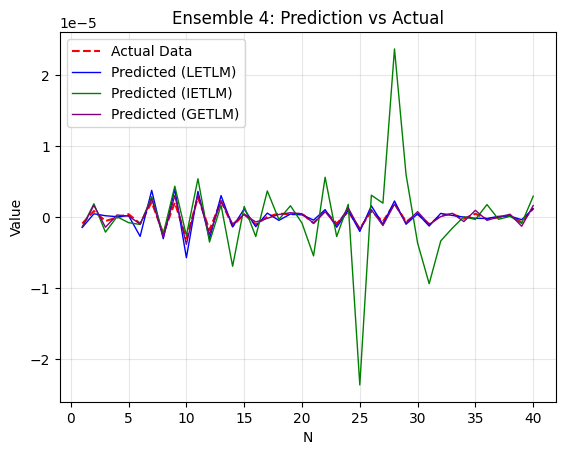

IETLM norm: tensor(3.0936)
LETLM norm: tensor(0.5835)
GETLM norm: tensor(0.3296)


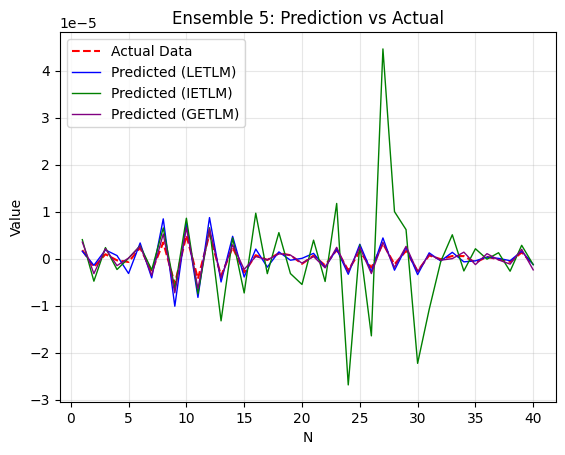

IETLM norm: tensor(3.1207)
LETLM norm: tensor(0.6870)
GETLM norm: tensor(0.4087)


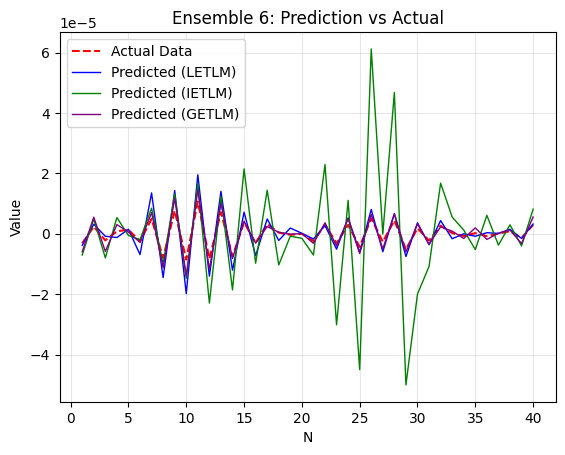

IETLM norm: tensor(3.3440)
LETLM norm: tensor(0.8340)
GETLM norm: tensor(0.4951)


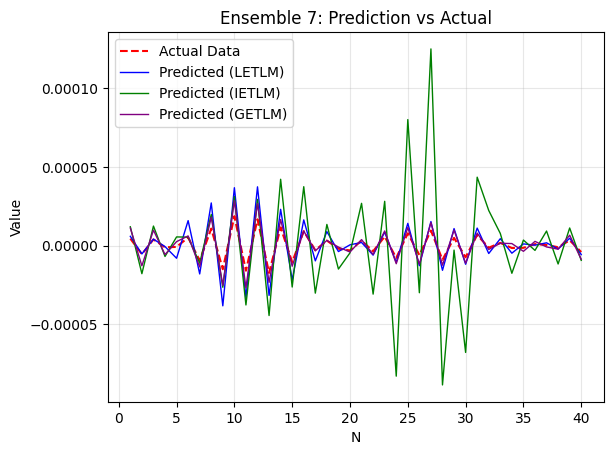

IETLM norm: tensor(3.5108)
LETLM norm: tensor(0.9951)
GETLM norm: tensor(0.6026)


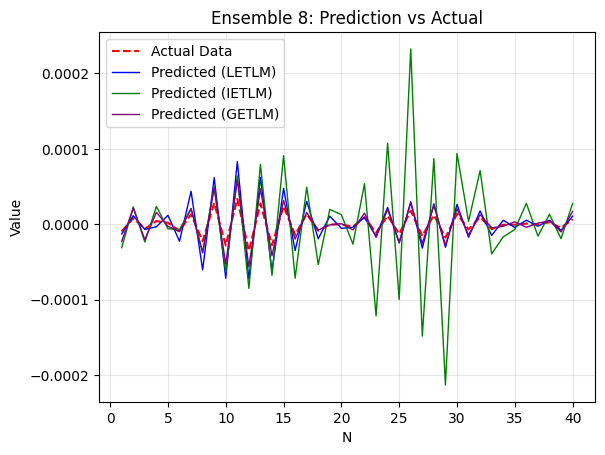

IETLM norm: tensor(3.8577)
LETLM norm: tensor(1.2097)
GETLM norm: tensor(0.7354)


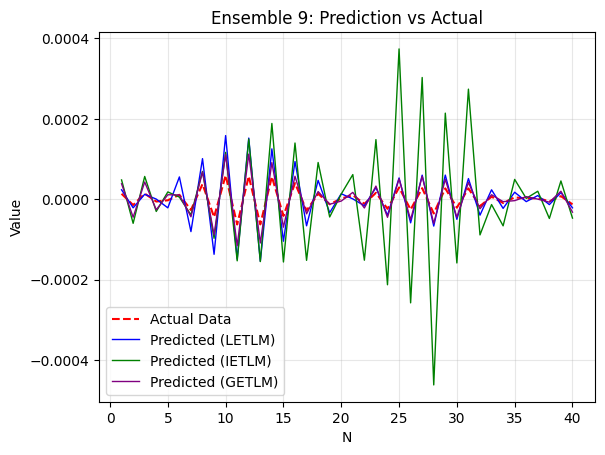

IETLM norm: tensor(4.1827)
LETLM norm: tensor(1.4157)
GETLM norm: tensor(0.8591)


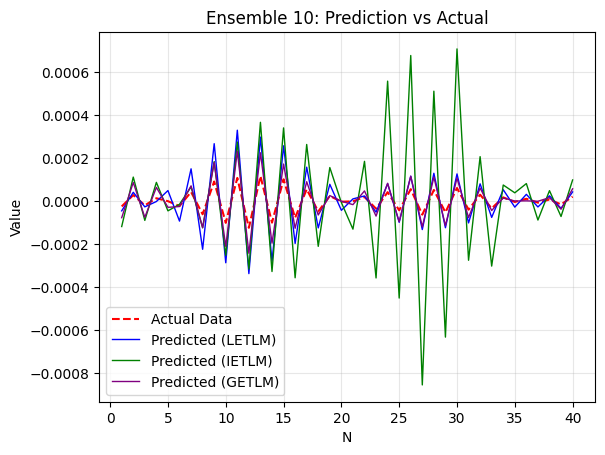

IETLM norm: tensor(4.6867)
LETLM norm: tensor(1.6545)
GETLM norm: tensor(1.0056)


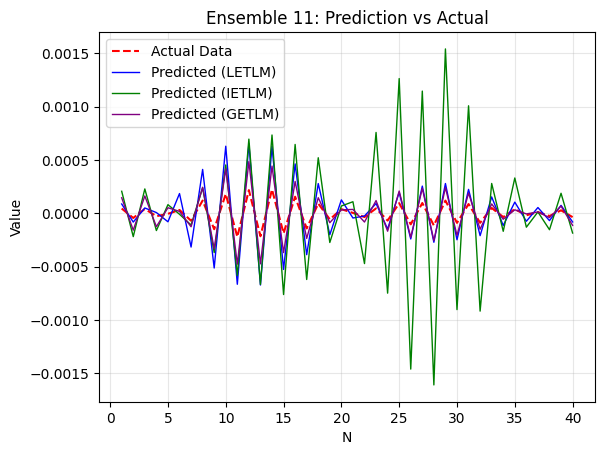

IETLM norm: tensor(5.1149)
LETLM norm: tensor(1.8982)
GETLM norm: tensor(1.1588)


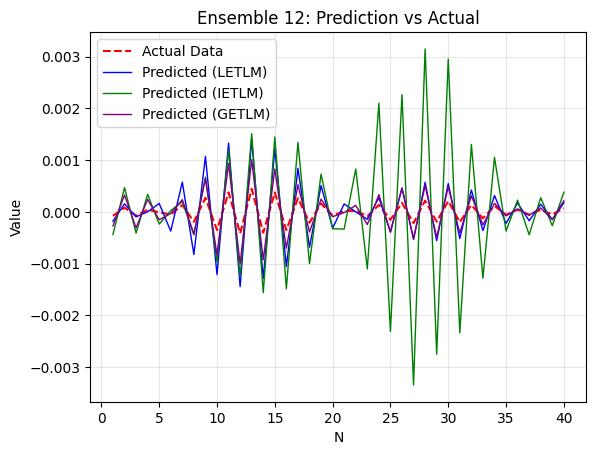

IETLM norm: tensor(5.7912)
LETLM norm: tensor(2.1741)
GETLM norm: tensor(1.3328)


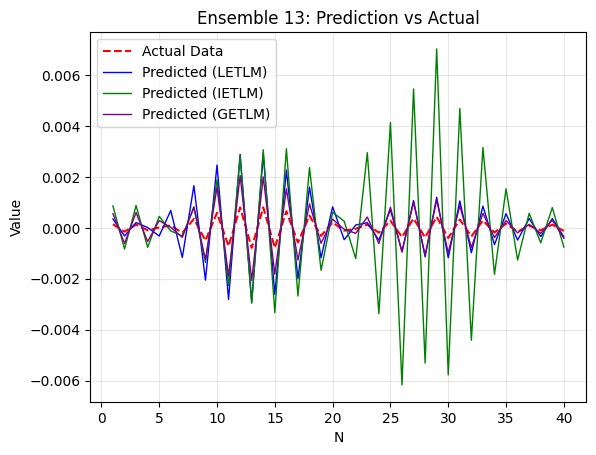

IETLM norm: tensor(6.3096)
LETLM norm: tensor(2.4697)
GETLM norm: tensor(1.5294)


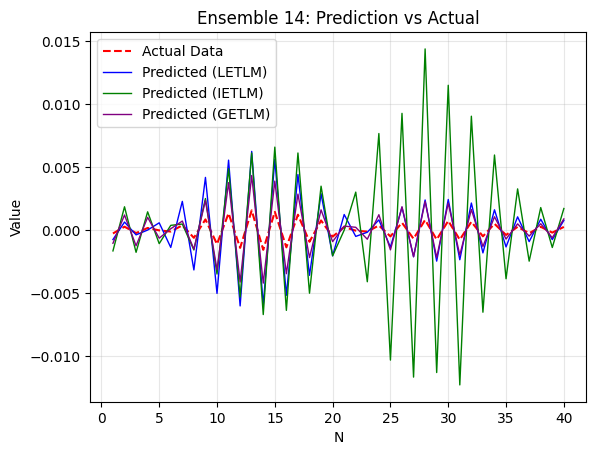

IETLM norm: tensor(7.0294)
LETLM norm: tensor(2.7977)
GETLM norm: tensor(1.7503)


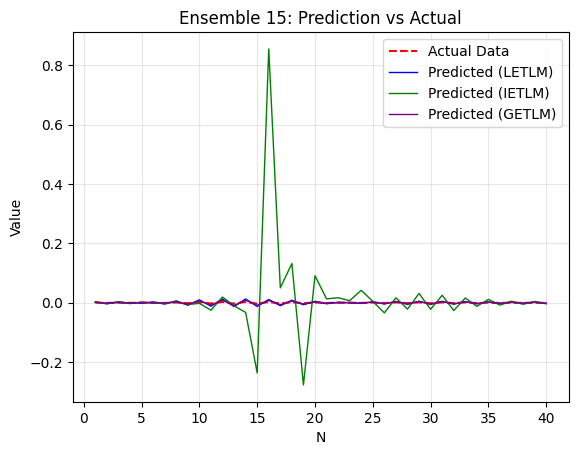

IETLM norm: tensor(41.9775)
LETLM norm: tensor(3.1461)
GETLM norm: tensor(1.9783)


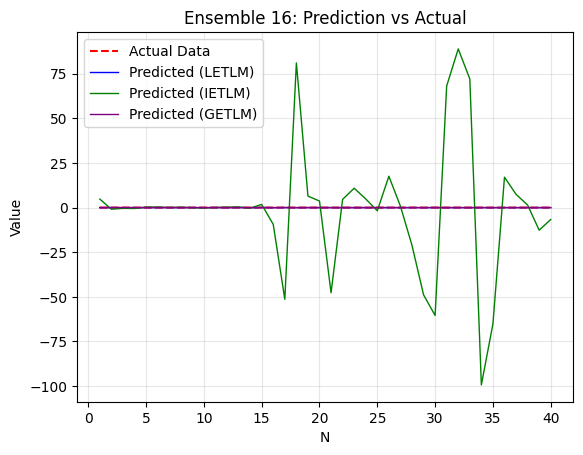

IETLM norm: tensor(8655.9646)
LETLM norm: tensor(3.5443)
GETLM norm: tensor(2.2351)


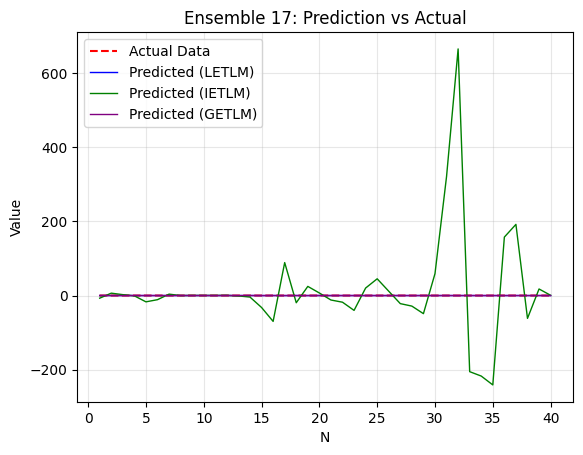

IETLM norm: tensor(14504.4652)
LETLM norm: tensor(3.9504)
GETLM norm: tensor(2.5095)


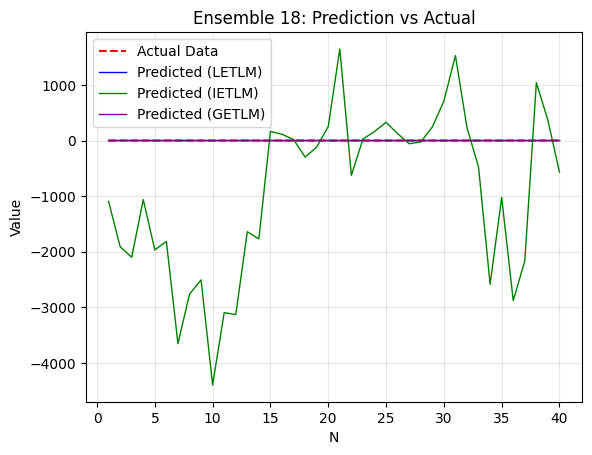

IETLM norm: tensor(141335.1847)
LETLM norm: tensor(4.4271)
GETLM norm: tensor(2.8123)


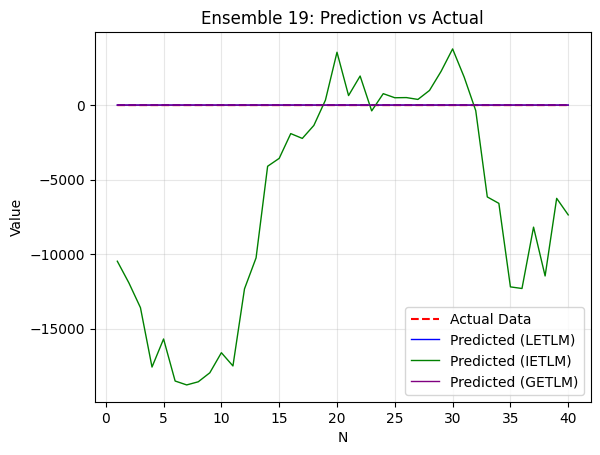

IETLM norm: tensor(431945.1583)
LETLM norm: tensor(4.9269)
GETLM norm: tensor(3.1372)


<Figure size 640x480 with 0 Axes>

In [109]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []

# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0
GETLM_test_future = test_0
GETLM_test_current = test_final[starting_time]

letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
getlm_norm = L2_norm(GETLM_test_future, test_0)

LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
GETLM_norm.append(getlm_norm)

plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final)-3):
    test = test_final[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    # plt.imshow(ietlm,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("2D Tensor Heatmap")
    # plt.title("N_tilde")
    # plt.show()

    GETLM_test_past = GETLM_test_current
    GETLM_test_current = GETLM_test_future

    NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
    NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past



    IETLM_test = ietlm @ IETLM_test

    # We now need to calculate the L2 norm

    letlm_norm = L2_norm(LETLM_test, test)
    ietlm_norm = L2_norm(IETLM_test, test)
    getlm_norm = L2_norm(GETLM_test_future, test)
    LETLM_norm.append(letlm_norm)
    IETLM_norm.append(ietlm_norm)
    GETLM_norm.append(getlm_norm)


    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

    plt.title(f"Ensemble {i+1}: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    print('IETLM norm:', ietlm_norm)
    print('LETLM norm:', letlm_norm)
    print('GETLM norm:', getlm_norm)

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



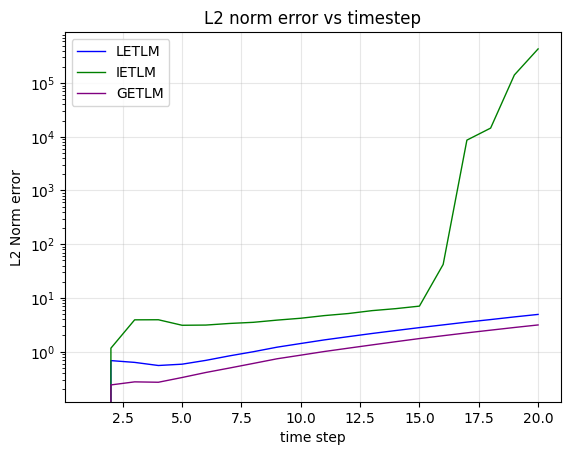

<Figure size 640x480 with 0 Axes>

In [113]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)
plt.yscale('log')
plt.plot(x_values_norm, LETLM_norm, label='LETLM', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_norm, label='IETLM', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_norm, label='GETLM', color='purple', linewidth=1)
plt.title("L2 norm error vs timestep")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()
